## Data Loading

### Mount Google Drive
We need to mount Google Drive to access your files in `/content/drive/MyDrive/`.

In [323]:
from google.colab import drive
import pandas as pd
import glob
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


# drive.mount('/content/drive')

In [179]:
DATA_DIR = '/content/drive/MyDrive/Student Analytics — Kayfa '

# CSV Files
courses = pd.read_csv(f"{DATA_DIR}/courses.csv")
groups = pd.read_csv(f"{DATA_DIR}/groups.csv")
students = pd.read_csv(f"{DATA_DIR}/students.csv")
concepts = pd.read_csv(f"{DATA_DIR}/concepts_performance.csv")
engagement = pd.read_csv(f"{DATA_DIR}/engagement_events.csv")
submissions = pd.read_csv(f"{DATA_DIR}/assignment_submissions.csv")

# JSON File (grades.json)
with open(f"{DATA_DIR}/grades.json", "r", encoding="utf-8") as f:
    grades_json = json.load(f)

grades = pd.json_normalize(
    grades_json,
    record_path='grades',
    meta=['student_id', 'course_id', 'group_id']
)

# Excel File (attendance.xlsx)
attendance_sheets = pd.read_excel(
    f"{DATA_DIR}/attendance.xlsx",
    sheet_name=None
)

attendance = pd.concat(
    attendance_sheets.values(),
    ignore_index=True
)

# View Shapes
dfs = {
    "courses": courses,
    "groups": groups,
    "students": students,
    "grades": grades,
    "attendance": attendance,
    "concepts": concepts,
    "engagement": engagement,
    "submissions": submissions
}

for name, df in dfs.items():
    print(f"{name}: {df.shape}")


courses: (7, 8)
groups: (12, 7)
students: (502, 8)
grades: (5502, 10)
attendance: (13010, 6)
concepts: (12008, 10)
engagement: (30866, 6)
submissions: (1504, 9)


*## Course Exploration & Cleaning*

In [180]:
courses.head()

,course_id,course_name,category,difficulty_level,duration_weeks,short_description,modules,is_active
0,C001,Data Analytics Fundamentals,Analytics,Beginner,12,Data Analytics Fundamentals — hands-on analyti...,"[""Spreadsheets & Tabular Data"", ""Descriptive S...",True
1,C002,Python Programming,Programming,Beginner,14,Python Programming — hands-on programming trac...,"[""Variables & Types"", ""Control Flow"", ""Functio...",True
2,C003,Web Development,Programming,Intermediate,16,Web Development — hands-on programming track a...,"[""HTML & Semantics"", ""CSS Layout"", ""JavaScript...",True
3,C004,UI/UX Design,Design,Beginner,10,UI/UX Design — hands-on design track at Kayfa.,"[""Design Principles"", ""Wireframing"", ""Color Th...",True
4,C005,Digital Marketing,Business,Beginner,8,Digital Marketing — hands-on business track at...,"[""SEO Basics"", ""Content Strategy"", ""Paid Ads"",...",True


In [181]:
# # check rows duplicates
if int(courses.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {courses.duplicated().sum()}")

No Duplicates


In [182]:
#  check id duplicates
if int(courses.course_id.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {courses.id.duplicated().sum()}")

No Duplicates


In [183]:
# info
courses.info()

# reults :
# 1 - all data types are correct
# 2 - no null values
# 3 - no duplicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   course_id          7 non-null      object
 1   course_name        7 non-null      object
 2   category           7 non-null      object
 3   difficulty_level   7 non-null      object
 4   duration_weeks     7 non-null      int64 
 5   short_description  7 non-null      object
 6   modules            7 non-null      object
 7   is_active          7 non-null      bool  
dtypes: bool(1), int64(1), object(6)
memory usage: 531.0+ bytes


In [184]:
# descripe
courses.describe()

# results :
# duration_weeks > 0 as needed and no anonmies founds

,duration_weeks
count,7.000000
mean,12.571429
std,2.992053
min,8.000000
25%,11.000000
50%,12.000000
75%,15.000000
max,16.000000


In [185]:
# Let's investigate into categorical data
for col in courses.select_dtypes(include=['object', 'category']).columns:
  if col == 'course_id':
    continue

  print(f"Column: {col}")
  print(courses[col].value_counts())
  print("\n")

  # results from outpot :
  # no inconsisstent adata in cousres tabels
  # all courses is active
  # 50 % of cousres for begginers

Column: course_name
course_name
Data Analytics Fundamentals    1
Python Programming             1
Web Development                1
UI/UX Design                   1
Digital Marketing              1
Machine Learning Basics        1
Cybersecurity Essentials       1
Name: count, dtype: int64


Column: category
category
Analytics      2
Programming    2
Design         1
Business       1
Security       1
Name: count, dtype: int64


Column: difficulty_level
difficulty_level
Beginner        4
Intermediate    2
Advanced        1
Name: count, dtype: int64


Column: short_description
short_description
Data Analytics Fundamentals — hands-on analytics track at Kayfa.    1
Python Programming — hands-on programming track at Kayfa.           1
Web Development — hands-on programming track at Kayfa.              1
UI/UX Design — hands-on design track at Kayfa.                      1
Digital Marketing — hands-on business track at Kayfa.               1
Machine Learning Basics — hands-on analytics track a

## Groups Exploration & Cleaning

In [186]:
groups.head(5)

,group_id,group_name,course_id,stated_num_students,session_day,session_time,instructor
0,G01,Group 01 — C001,C001,52,Thursday,16:00,Eng. Khaled Adel
1,G02,Group 02 — C001,C001,56,Thursday,18:00,Dr. Mona Saad
2,G03,Group 03 — C002,C002,67,Sunday,6 PM,Dr. Laila ElBaz
3,G04,Group 04 — C002,C002,65,Saturday,16:00,Eng. Hossam Refaat
4,G05,Group 05 — C003,C003,76,Tuesday,1800,Eng. Khaled Adel


In [187]:
# # check rows duplicates
if int(groups.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {groups.duplicated().sum()}")

Duplicates Found : => 1


In [188]:
#  check id duplicates
if int(groups.group_id.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {groups.group_id.duplicated().sum()}")

Duplicates Found : => 1


In [189]:
## remove duplicates
groups.drop_duplicates(inplace=True)

In [190]:
# info
groups.info()

# reults :
# 1 - all data types are correct
# 2 - no null values
# 3 - no duplicates

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   group_id             11 non-null     object
 1   group_name           11 non-null     object
 2   course_id            11 non-null     object
 3   stated_num_students  11 non-null     int64 
 4   session_day          11 non-null     object
 5   session_time         11 non-null     object
 6   instructor           10 non-null     object
dtypes: int64(1), object(6)
memory usage: 704.0+ bytes


In [191]:
# descripe
groups.describe()

# results :
# we found a group with 0 students

,stated_num_students
count,11.000000
mean,53.090909
std,21.267132
min,0.000000
25%,51.500000
50%,56.000000
75%,66.000000
max,76.000000


In [192]:
# group with 0 students
groups[groups['stated_num_students'] == 0]

# we will not delete for now it can be students linked with it so from this we can now the stated_num_students

,group_id,group_name,course_id,stated_num_students,session_day,session_time,instructor
10,G99,TEST_GROUP_DELETE,C001,0,Friday,00:00,NaN


In [193]:
groups.head(50)

,group_id,group_name,course_id,stated_num_students,session_day,session_time,instructor
0,G01,Group 01 — C001,C001,52,Thursday,16:00,Eng. Khaled Adel
1,G02,Group 02 — C001,C001,56,Thursday,18:00,Dr. Mona Saad
2,G03,Group 03 — C002,C002,67,Sunday,6 PM,Dr. Laila ElBaz
3,G04,Group 04 — C002,C002,65,Saturday,16:00,Eng. Hossam Refaat
4,G05,Group 05 — C003,C003,76,Tuesday,1800,Eng. Khaled Adel
5,G06,Group 06 — C004,C004,56,Saturday,17:00,Dr. Mona Saad
6,G07,Group 07 — C005,C005,70,Wednesday,21:00,Eng. Hossam Refaat
7,G08,Group 08 — C006,C006,60,Saturday,17:00,Dr. Laila ElBaz
8,G09,Group 09 — C006,C006,51,Thursday,19:00,Dr. Mona Saad
9,G10,Group 10 — C007,C007,31,Tuesday,18:00,Eng. Khaled Adel


In [194]:
# deald with inconssintent with data G03,G05
time_corrections = {
    '6 PM': '18:00',
    '1800': '18:00'
}
groups['session_time'] = groups['session_time'].replace(time_corrections)

In [195]:
# check if it's updated
groups[groups['group_id'] == 'G03']

,group_id,group_name,course_id,stated_num_students,session_day,session_time,instructor
2,G03,Group 03 — C002,C002,67,Sunday,18:00,Dr. Laila ElBaz


In [196]:
# check inconssistent in session_day
groups['session_day'].value_counts()

,count
session_day,
Thursday,3
Saturday,3
Tuesday,2
Sunday,1
Wednesday,1
Friday,1


In [197]:
# check all the groups are linked with the existing course id
print(groups['course_id'].unique())
print(courses['course_id'].unique())


['C001' 'C002' 'C003' 'C004' 'C005' 'C006' 'C007']
['C001' 'C002' 'C003' 'C004' 'C005' 'C006' 'C007']


In [198]:
groups['instructor'].unique()

array(['Eng. Khaled Adel', 'Dr. Mona Saad', 'Dr. Laila ElBaz',
       'Eng. Hossam Refaat', nan], dtype=object)

## students Exploration & Cleaning

In [199]:
students.head(50)

,student_id,full_name,age,gender,city,email,group_id,enrollment_date
0,S0001,Hana Gamal,27,Male,Mansoura,hana.gamal@kayfa-student.io,G03,2025-12-14
1,S0002,Mona Abdelaziz,25,Female,Zagazig,mona.abdelaziz@kayfa-student.io,G06,2025-12-03
2,S0003,Menna Naguib,20,Male,Ismailia,menna.naguib@kayfa-student.io,G05,2025-12-17
3,S0004,Aya ElShafei,21,Male,Giza,aya.elshafei@kayfa-student.io,G02,2025-12-12
4,S0005,Habiba Mahmoud,24,Male,Giza,habiba.mahmoud@kayfa-student.io,G01,2025-12-14
5,S0006,Aya ElSayed,18,Female,Zagazig,aya.elsayed@kayfa-student.io,G07,2025-12-06
6,S0007,Omar Darwish,25,Male,Asyut,omar.darwish@kayfa-student.io,G04,2025-12-14
7,S0008,Mona Gamal,25,Male,Zagazig,mona.gamal@kayfa-student.io,G04,2025-12-04
8,S0009,Mahmoud Awad,23,Female,Ismailia,mahmoud.awad@kayfa-student.io,G01,2025-12-05
9,S0010,Abdelrahman ElBaz,25,Female,Mansoura,abdelrahman.elbaz@kayfa-student.io,G05,2025-12-02


In [200]:
# info
students.info()

# reults :
# 1 - all data types are correct except enrollment_date
# 2 -  null values for full_name

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   student_id       502 non-null    object
 1   full_name        498 non-null    object
 2   age              502 non-null    int64 
 3   gender           502 non-null    object
 4   city             502 non-null    object
 5   email            502 non-null    object
 6   group_id         502 non-null    object
 7   enrollment_date  502 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.5+ KB


In [201]:
students['enrollment_date'] = pd.to_datetime(students['enrollment_date'])
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   student_id       502 non-null    object        
 1   full_name        498 non-null    object        
 2   age              502 non-null    int64         
 3   gender           502 non-null    object        
 4   city             502 non-null    object        
 5   email            502 non-null    object        
 6   group_id         502 non-null    object        
 7   enrollment_date  502 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 31.5+ KB


In [202]:
# أقل تاريخ
min_date = students['enrollment_date'].min()

# أكبر تاريخ
max_date = students['enrollment_date'].max()

print("Earliest enrollment_date:", min_date)
print("Latest enrollment_date:", max_date)


Earliest enrollment_date: 2025-12-01 00:00:00
Latest enrollment_date: 2025-12-20 00:00:00


In [203]:
# # check rows duplicates
if int(students.duplicated().sum()) == 0 :
  print("No Rows Duplicates")
else:
  print(f"Duplicates Found : => {students.duplicated().sum()}")

No Rows Duplicates


In [204]:
#  check id duplicates
if int(students.student_id.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {students.student_id.duplicated().sum()}")

Duplicates Found : => 2


In [205]:
# investigate thoses ids Duplicates
students[students.duplicated(subset=['student_id'], keep=False)]

,student_id,full_name,age,gender,city,email,group_id,enrollment_date
73,S0074,Sherif Zaki,25,Female,Alexandria,sherif.zaki@kayfa-student.io,G08,2025-12-09
361,S0362,Hana Mansour,17,Male,Tanta,hana.mansour@kayfa-student.io,G08,2025-12-16
500,S0362,Hana Mansour,99,Male,Tanta,hana.mansour@kayfa-student.io,G08,2025-12-16
501,S0074,Sherif Zaki,88,Female,Alexandria,sherif.zaki@kayfa-student.io,G08,2025-12-09


In [206]:
# found that ids Duplicates the only change in the age we will remove that duplicates with unusual age

# Decide which ages are unusual
# For example, keep the minimum age (more realistic) and drop the rest
students = students.sort_values('age').drop_duplicates(subset=['student_id'], keep='first')
students

,student_id,full_name,age,gender,city,email,group_id,enrollment_date
208,S0209,Marwan Naguib,-22,Female,Giza,marwan.naguib@kayfa-student.io,G03,2025-12-12
452,S0453,Marwan ElBaz,-5,Male,Zagazig,marwan.elbaz@kayfa-student.io,G07,2025-12-10
22,S0023,Tarek Gamal,4,Female,Mansoura,@kayfa.io,G08,2025-12-19
497,S0498,Jana Halim,17,Female,Cairo,jana.halim@kayfa-student.io,G03,2025-12-12
456,S0457,Mostafa Hassan,17,Female,Giza,mostafa.hassan@kayfa-student.io,G02,2025-12-07
...,...,...,...,...,...,...,...,...
101,S0102,Farida ElShafei,30,Female,Ismailia,farida.elshafei@kayfa-student.io,G02,2025-12-12
403,S0404,Hana Gamal,30,Female,Fayoum,hana.gamal@kayfa-student.io,G09,2025-12-14
312,S0313,Sara Farouk,31,Female,Mansoura,sara.farouk@kayfa-student.io,G01,2025-12-04
415,S0416,Seif Farouk,31,Male,Cairo,seif.farouk@kayfa-student.io,G07,2025-12-08


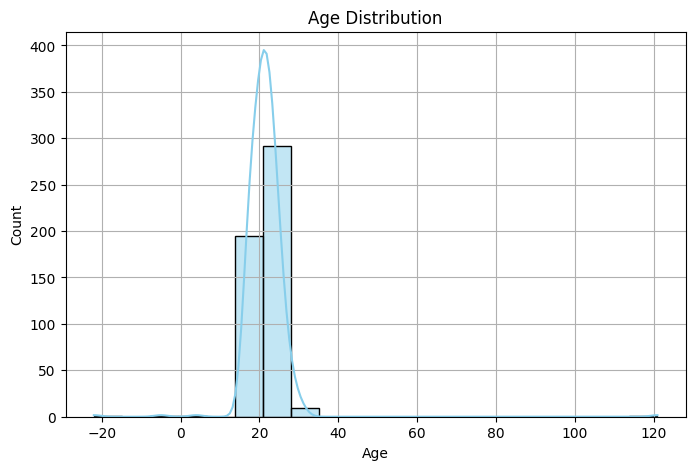

In [207]:
# there is a negative age values and unusual age like 121
# Histogram for age distribution
plt.figure(figsize=(8,5))
sns.histplot(students['age'], bins=20, kde=True, color='skyblue').grid(True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# results :
# we found a group with 0 students

In [208]:
# descripe
students.describe()

# results :
# we found a age with negative it must be +
# and max age is 121

,age,enrollment_date
count,500.00000,500
mean,21.46400,2025-12-10 08:09:36
min,-22.00000,2025-12-01 00:00:00
25%,19.00000,2025-12-05 00:00:00
50%,21.00000,2025-12-10 00:00:00
75%,23.00000,2025-12-15 00:00:00
max,121.00000,2025-12-20 00:00:00
std,5.89731,NaN


In [209]:
# make negative age value + with np.where
students['age'] = np.where(
    students['age'] < 0,
    -students['age'],
    students['age']
    )

In [210]:
# let's see if it has been updated
students.describe()

,age,enrollment_date
count,500.000000,500
mean,21.572000,2025-12-10 08:09:36
min,4.000000,2025-12-01 00:00:00
25%,19.000000,2025-12-05 00:00:00
50%,21.000000,2025-12-10 00:00:00
75%,23.000000,2025-12-15 00:00:00
max,121.000000,2025-12-20 00:00:00
std,5.488265,NaN


In [211]:
# let's deal with thoses max values and check is 121 value age in the only unusual age or there is many
students.sort_values('age').tail(10)

,student_id,full_name,age,gender,city,email,group_id,enrollment_date
50,S0051,Hana Fathy,29,Female,Asyut,hana.fathy@kayfa-student.io,G05,2025-12-13
317,S0318,Abdelrahman Sultan,29,Female,Mansoura,abdelrahman.sultan@kayfa-student.io,G03,2025-12-17
123,S0124,Dina Farouk,29,Male,Port Said,dina.farouk@kayfa-student.io,G02,2025-12-17
101,S0102,Farida ElShafei,30,Female,Ismailia,farida.elshafei@kayfa-student.io,G02,2025-12-12
308,S0309,Abdelrahman Ibrahim,30,Male,Giza,abdelrahman.ibrahim@kayfa-student.io,G06,2025-12-17
403,S0404,Hana Gamal,30,Female,Fayoum,hana.gamal@kayfa-student.io,G09,2025-12-14
182,S0183,Esraa Hassan,30,Female,Port Said,esraa.hassan@kayfa-student.io,G02,2025-12-14
415,S0416,Seif Farouk,31,Male,Cairo,seif.farouk@kayfa-student.io,G07,2025-12-08
312,S0313,Sara Farouk,31,Female,Mansoura,sara.farouk@kayfa-student.io,G01,2025-12-04
477,S0478,Nada Abdelaziz,121,Male,Tanta,nada.abdelaziz@kayfa-student.io,G09,2025-12-05


In [212]:
# Calculate the average age
avg_age = students['age'].mean()

# Update Nada's age safely
students.loc[students['student_id'] == 'S0478', 'age'] = avg_age

# Check the last 10 rows sorted by age
students.sort_values('age').tail(10)

/tmp/ipykernel_965/758925328.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '21.572' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  students.loc[students['student_id'] == 'S0478', 'age'] = avg_age


,student_id,full_name,age,gender,city,email,group_id,enrollment_date
124,S0125,Abdelrahman Mansour,28.0,Male,Mansoura,abdelrahman.mansour@kayfa-student.io,G01,2025-12-04
50,S0051,Hana Fathy,29.0,Female,Asyut,hana.fathy@kayfa-student.io,G05,2025-12-13
123,S0124,Dina Farouk,29.0,Male,Port Said,dina.farouk@kayfa-student.io,G02,2025-12-17
317,S0318,Abdelrahman Sultan,29.0,Female,Mansoura,abdelrahman.sultan@kayfa-student.io,G03,2025-12-17
101,S0102,Farida ElShafei,30.0,Female,Ismailia,farida.elshafei@kayfa-student.io,G02,2025-12-12
403,S0404,Hana Gamal,30.0,Female,Fayoum,hana.gamal@kayfa-student.io,G09,2025-12-14
182,S0183,Esraa Hassan,30.0,Female,Port Said,esraa.hassan@kayfa-student.io,G02,2025-12-14
308,S0309,Abdelrahman Ibrahim,30.0,Male,Giza,abdelrahman.ibrahim@kayfa-student.io,G06,2025-12-17
415,S0416,Seif Farouk,31.0,Male,Cairo,seif.farouk@kayfa-student.io,G07,2025-12-08
312,S0313,Sara Farouk,31.0,Female,Mansoura,sara.farouk@kayfa-student.io,G01,2025-12-04


In [213]:
# deals with full_name nulls
students.loc[students['full_name'].isnull(), ['student_id','email']] #= students.loc[students['full_name'].isnull(), 'student_id']

,student_id,email
286,S0287,nada.gamal@kayfa-student.io
365,S0366,fady.elghandour@kayfa-student.io
108,S0109,khaled.gamal@kayfa-student.io
134,S0135,farida.elbaz@kayfa-student.io


In [214]:
# students.loc[students['full_name'].isnull(), ['student_id','email']] = students.loc[students['full_name'].isnull(), 'email']
# if dull_names is null impute it with email
students.loc[students['full_name'].isnull(), 'full_name'] = (
    students.loc[students['full_name'].isnull(), 'email']
    .str.split('@').str[0]              # ناخد الجزء قبل @
    .str.replace('.', ' ')              # نحول النقاط لمسافات
    .str.title()                        # نخلي أول حرف كابيتال
)

print(students[students['full_name'].isnull()][['student_id','full_name','email']])

Empty DataFrame
Columns: [student_id, full_name, email]
Index: []


In [215]:
students.duplicated().sum()

np.int64(0)

In [216]:
import re

# returns all incorrect patterns of emails
pattern = r'^[a-z]+\.[a-z]+@kayfa-student\.io$'

# نجيب الصفوف اللي مش ماشية على الشكل ده
invalid_emails = students[~students['email'].str.match(pattern)]
invalid_emails[['student_id','full_name','email']]

,student_id,full_name,email
22,S0023,Tarek Gamal,@kayfa.io
60,S0061,Karim AbdelHamid,spaces here@x.io
61,S0062,Menna ElGhandour,not-an-email
14,S0015,Fady ElMasry,missing@


In [217]:
# نعدل الإيميلات اللي مش ماشية على الـ pattern
students.loc[~students['email'].str.match(pattern), 'email'] = (
    students.loc[~students['email'].str.match(pattern), 'full_name']
    .str.strip()                       # نشيل المسافات
    .str.lower()                       # نخليها lowercase
    .str.replace(' ', '.', regex=False) # نحول المسافات لنقطة
    + '@kayfa-student.io'              # نضيف الدومين
)

# نراجع بعد التعديل
students[~students['email'].str.match(pattern)][['student_id','full_name','email']]

,student_id,full_name,email


In [218]:
# one last check
students[students['student_id'] == 'S0023']

,student_id,full_name,age,gender,city,email,group_id,enrollment_date
22,S0023,Tarek Gamal,4.0,Female,Mansoura,tarek.gamal@kayfa-student.io,G08,2025-12-19


In [219]:
# let's check if all groups linked with students are exists
all_in_groups = students['group_id'].isin(groups['group_id']).all()

print("Are all group_id in students present in groups?", all_in_groups)

Are all group_id in students present in groups? False


In [220]:
missing_groups = students.loc[~students['group_id'].isin(groups['group_id']), 'group_id'].unique()
print("Missing group_id values:", missing_groups)

Missing group_id values: ['GZZ' 'G77']


In [221]:
# let's investigate it Missing group_id values: ['GZZ' 'G77']

students[students['group_id'].isin(missing_groups)]

,student_id,full_name,age,gender,city,email,group_id,enrollment_date
13,S0014,Ali Refaat,17.0,Male,Ismailia,ali.refaat@kayfa-student.io,GZZ,2025-12-18
322,S0323,Aya Kamel,22.0,Female,Zagazig,aya.kamel@kayfa-student.io,G77,2025-12-18
94,S0095,Yasmin Fathy,22.0,Female,Zagazig,yasmin.fathy@kayfa-student.io,G77,2025-12-06


In [222]:
print(groups['group_id'].values)

['G01' 'G02' 'G03' 'G04' 'G05' 'G06' 'G07' 'G08' 'G09' 'G10' 'G99']


In [223]:
#  we will deal with it later for example in grade we may know which group acutlry student enrolled at




In [224]:
# somthing is wrong with gender Ali is female and some females are males ans the oppsite

# Split full_name into first_name and last_name
students[['first_name', 'last_name']] = students['full_name'].str.split(' ', n=1, expand=True)

# Check result
students[['student_id', 'full_name', 'first_name', 'last_name']].head()

,student_id,full_name,first_name,last_name
208,S0209,Marwan Naguib,Marwan,Naguib
452,S0453,Marwan ElBaz,Marwan,ElBaz
22,S0023,Tarek Gamal,Tarek,Gamal
497,S0498,Jana Halim,Jana,Halim
456,S0457,Mostafa Hassan,Mostafa,Hassan


In [225]:
# by splitting i can get all the unique nammes and spesify gender basod on it
unique_names = students['first_name'].unique()
unique_names

array(['Marwan', 'Tarek', 'Jana', 'Mostafa', 'Habiba', 'Yasmin', 'Sara',
       'Omar', 'Mona', 'Salma', 'Abdelrahman', 'Khaled', 'Fady', 'Sherif',
       'Rowan', 'Ziad', 'Adel', 'Karim', 'Mahmoud', 'Nada', 'Menna',
       'Rana', 'Seif', 'Hana', 'Hossam', 'Ali', 'Dina', 'Mariam', 'Esraa',
       'Nour', 'Mohamed', 'Hassan', 'Aya', 'Laila', 'Youssef', 'Malak',
       'Farida', 'Amr', '', 'Ahmed'], dtype=object)

In [226]:
# Define male and female name lists
male_names = {'Marwan','Tarek','Mostafa','Omar','Abdelrahman','Khaled','Fady',
              'Sherif','Ziad','Adel','Karim','Mahmoud','Seif','Hossam','Ali',
              'Mohamed','Hassan','Youssef','Amr','Ahmed'}

female_names = {'Jana','Habiba','Yasmin','Sara','Mona','Salma','Rowan','Nada',
                'Menna','Rana','Hana','Dina','Mariam','Esraa','Nour','Aya',
                'Laila','Malak','Farida'}

# Function to classify gender
def classify_gender(name):
    if name in male_names:
        return "Male"
    elif name in female_names:
        return "Female"
    else:
        return name  # keep original if ambiguous or empty

# Apply classification to students DataFrame
students['gender_from_name'] = students['first_name'].apply(classify_gender)

# Check result
students[['student_id','full_name','first_name','gender_from_name']].head(20)

,student_id,full_name,first_name,gender_from_name
208,S0209,Marwan Naguib,Marwan,Male
452,S0453,Marwan ElBaz,Marwan,Male
22,S0023,Tarek Gamal,Tarek,Male
497,S0498,Jana Halim,Jana,Female
456,S0457,Mostafa Hassan,Mostafa,Male
453,S0454,Habiba Soliman,Habiba,Female
43,S0044,Yasmin Ramadan,Yasmin,Female
498,S0499,Mostafa Nasr,Mostafa,Male
304,S0305,Tarek Shawky,Tarek,Male
333,S0334,Marwan ElShafei,Marwan,Male


In [227]:
# no student is  linked to G99 delete it
print(f"groups in students df: {students['group_id'].unique()}")
print(f"groups in groups df : {groups['group_id'].unique()}")

# delete it
groups = groups[~groups['group_id'].isin(['G99'])]

groups in students df: ['G03' 'G07' 'G08' 'G02' 'G01' 'G04' 'G06' 'G09' 'G05' 'GZZ' 'G10' 'G77']
groups in groups df : ['G01' 'G02' 'G03' 'G04' 'G05' 'G06' 'G07' 'G08' 'G09' 'G10' 'G99']


In [228]:
students['gender'].unique()

array(['Female', 'Male', 'M', 'F', 'Fem', 'MALE', 'female', 'male', 'f',
       'm'], dtype=object)

## Grades Exploration & Cleaning

In [229]:
grades

,grade_id,assessment_id,assessment_title,type,score,max_score,date,student_id,course_id,group_id
0,GR00001,C002-QZ,Quiz 1,quiz,-10.0,100,2025-12-27,S0001,C002,G03
1,GR00002,C002-QZ,Quiz 2,quiz,69.1,100,2026-01-10,S0001,C002,G03
2,GR00003,C002-QZ,Quiz 3,quiz,84.6,100,2026-01-24,S0001,C002,G03
3,GR00004,C002-QZ,Quiz 4,quiz,88.2,100,2026-02-07,S0001,C002,G03
4,GR00005,C002-AS,Assignment 1,assignment,67.4,100,2026-02-21,S0001,C002,G03
...,...,...,...,...,...,...,...,...,...,...
5497,GR05496,C007-AS,Assignment 3,assignment,62.2,100,2026-03-19,S0500,C007,G10
5498,GR05497,C007-PR,Practical 1,practical,78.8,100,2026-04-03,S0500,C007,G10
5499,GR05498,C007-PR,Practical 2,practical,84.9,100,2026-04-17,S0500,C007,G10
5500,GR05499,C007-EX,Midterm Exam,exam,84.0,100,2026-05-01,S0500,C007,G10


In [230]:
# # check rows duplicates
if int(grades.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {grades.duplicated().sum()}")

No Duplicates


In [231]:
#  check id duplicates
if int(grades.grade_id.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {grades.grade_id.duplicated().sum()}")

No Duplicates


In [232]:
# info
grades.info()

# reults :
# 1 - all data types are correct except date
# 2 - no null values
# 3 - no duplicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5502 entries, 0 to 5501
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   grade_id          5502 non-null   object 
 1   assessment_id     5502 non-null   object 
 2   assessment_title  5502 non-null   object 
 3   type              5502 non-null   object 
 4   score             5500 non-null   float64
 5   max_score         5502 non-null   int64  
 6   date              5502 non-null   object 
 7   student_id        5502 non-null   object 
 8   course_id         5502 non-null   object 
 9   group_id          5502 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 430.0+ KB


In [233]:
grades['date'] = pd.to_datetime(grades['date'])
grades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5502 entries, 0 to 5501
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   grade_id          5502 non-null   object        
 1   assessment_id     5502 non-null   object        
 2   assessment_title  5502 non-null   object        
 3   type              5502 non-null   object        
 4   score             5500 non-null   float64       
 5   max_score         5502 non-null   int64         
 6   date              5502 non-null   datetime64[ns]
 7   student_id        5502 non-null   object        
 8   course_id         5502 non-null   object        
 9   group_id          5502 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 430.0+ KB


In [234]:
# descripe
grades.describe()

# results :
# score should be >= 0  no negative vals nad no score > 100

,score,max_score,date
count,5500.000000,5502.000000,5502
mean,70.506200,99.983642,2026-03-05 07:06:36.510359808
min,-10.000000,10.000000,2025-12-16 00:00:00
25%,62.375000,100.000000,2026-01-25 00:00:00
50%,70.700000,100.000000,2026-03-05 00:00:00
75%,79.300000,100.000000,2026-04-16 00:00:00
max,187.000000,100.000000,2026-05-16 00:00:00
std,12.590239,1.213339,NaN


In [235]:
print(grades.loc[grades['score'] < 0, 'score'])

# Fixed: Multiply the values by -1, not the column name string
grades.loc[grades['score'] < 0, 'score'] = grades.loc[grades['score'] < 0, 'score'] * -1
grades.loc[grades['score'] > 100, 'score'] = 100

0   -10.0
Name: score, dtype: float64


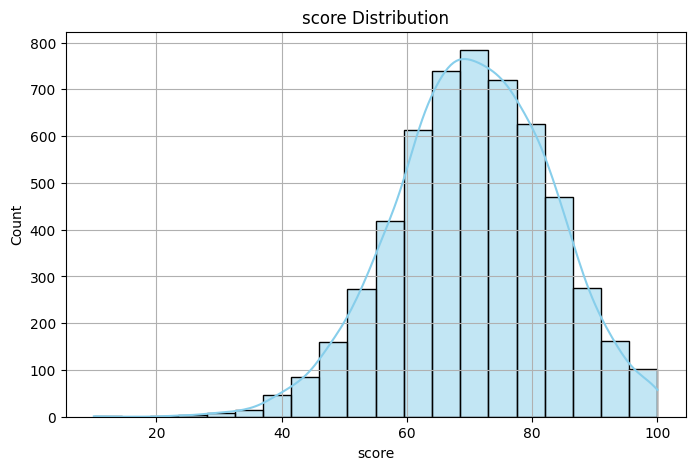

In [236]:
# Histogram for score distribution
plt.figure(figsize=(8,5))
sns.histplot(grades['score'], bins=20, kde=True, color='skyblue').grid(True)
plt.title("score Distribution")
plt.xlabel("score")
plt.ylabel("Count")
plt.show()

# results :
# we found a group with 0 students

In [237]:
# Let's investigate into categorical data
for col in grades.select_dtypes(include=['object', 'category']).columns:
  if col in ['grade_id','assessment_id','student_id','course_id','group_id']:
    continue

  print(f"Column: {col}")
  print(grades[col].value_counts())
  print("\n")

  # results from outpot :
  # no inconsisstent adata in cousres tabels

Column: assessment_title
assessment_title
Final Exam      501
Quiz 1          500
Quiz 3          500
Quiz 2          500
Quiz 4          500
Assignment 1    500
Assignment 3    500
Assignment 2    500
Practical 1     500
Practical 2     500
Midterm Exam    500
Bonus Exam        1
Name: count, dtype: int64


Column: type
type
quiz          2000
assignment    1500
exam          1002
practical     1000
Name: count, dtype: int64




In [238]:
# Integrity Check for Grades DataFrame
# Define the checks
checks = [
    ('student_id', students, 'students'),
    ('course_id', courses, 'courses'),
    ('group_id', groups, 'groups')
]

print("--- Integrity Check for Grades DataFrame ---\n")

for col, reference_df, ref_name in checks:
    # Find IDs in grades that are NOT in the reference table
    invalid_ids = grades[~grades[col].isin(reference_df[col])][col].unique()

    if len(invalid_ids) == 0:
        print(f"All {col}s in grades exist in the {ref_name} table.")
    else:
        print(f"Found {len(invalid_ids)} {col}(s) in grades NOT present in {ref_name}: {invalid_ids}")

        # Optional: show how many rows are affected
        affected_rows = grades[~grades[col].isin(reference_df[col])].shape[0]
        print(f"   Total affected rows in grades: {affected_rows}")

--- Integrity Check for Grades DataFrame ---

All student_ids in grades exist in the students table.
All course_ids in grades exist in the courses table.
All group_ids in grades exist in the groups table.


### Checking Grades Date Range vs Course Duration
We will check if any grade dates fall outside the expected timeframe (Enrollment Start + Duration in Weeks).

### 📖 Definition of **Enrollment Date**
- **Enrollment Date** = *The date the student officially registered in the system or institution.*
- It represents the **administrative registration date**, not necessarily the start of classes, first session, or the beginning of a specific course.

---

### 🚫 What it is **NOT**
- It is **not** the date the student started studying.  
- It is **not** the date of the first lecture/session.  
- It is **not** the start date of a particular course.  

---

### ✅ Correct English phrasing
> **Enrollment Date**: The date the student enrolled (registered) in the institution/system.  
> It indicates when the student became officially part of the school/university records, but it does not mean the actual start of classes or courses.


In [239]:
# Refined Check: Calculate validity based on individual student enrollment dates

# 1. Merge grades with student enrollment info and course duration
grades_refined = grades.merge(students[['student_id', 'enrollment_date']], on='student_id', how='left')
grades_refined = grades_refined.merge(courses[['course_id', 'duration_weeks']], on='course_id', how='left')

# 2. Calculate the specific expected end date for each student-course pair
grades_refined['expected_end_date'] = grades_refined['enrollment_date'] + pd.to_timedelta(grades_refined['duration_weeks'], unit='W')

# 3. Identify anomalies
# Grade before enrollment
before_enrollment = grades_refined[grades_refined['date'] < grades_refined['enrollment_date']]
# Grade after course duration
after_duration = grades_refined[grades_refined['date'] > grades_refined['expected_end_date']]

print(f"Results based on individual student enrollment:")
print(f"- Grades recorded BEFORE enrollment: {len(before_enrollment)}")
print(f"- Grades recorded AFTER course end: {len(after_duration)}")

if not after_duration.empty:
    print("\nExamples of grades recorded after expected duration:")
    display(after_duration[['student_id', 'course_id', 'enrollment_date', 'date', 'expected_end_date']].head())

Results based on individual student enrollment:
- Grades recorded BEFORE enrollment: 0
- Grades recorded AFTER course end: 2517

Examples of grades recorded after expected duration:


,student_id,course_id,enrollment_date,date,expected_end_date
7,S0001,C002,2025-12-14,2026-04-04,2026-03-22
8,S0001,C002,2025-12-14,2026-04-18,2026-03-22
9,S0001,C002,2025-12-14,2026-05-02,2026-03-22
10,S0001,C002,2025-12-14,2026-05-16,2026-03-22
15,S0002,C004,2025-12-03,2026-02-15,2026-02-11


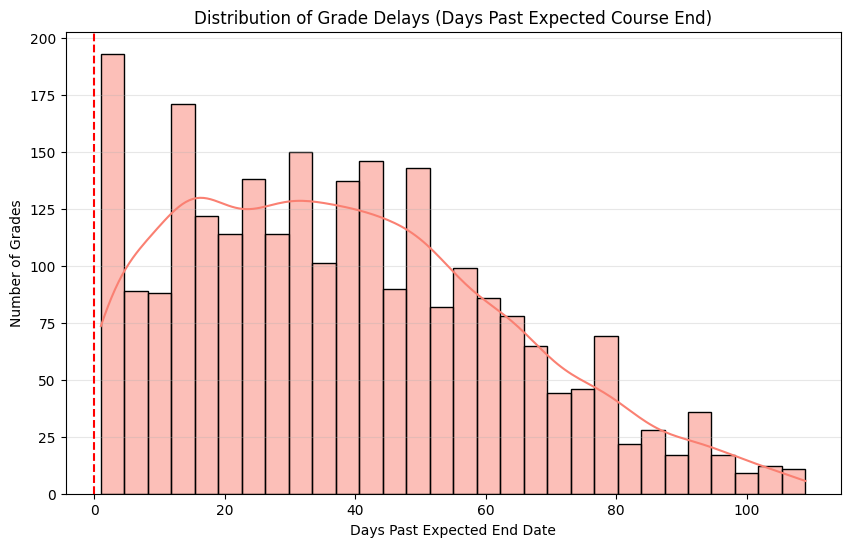

Median delay: 36.0 days
Maximum delay: 109 days


In [240]:
# Calculate the delay in days for grades after the expected end date
after_duration = after_duration.copy()
after_duration['days_past_end'] = (after_duration['date'] - after_duration['expected_end_date']).dt.days

plt.figure(figsize=(10, 6))
sns.histplot(after_duration['days_past_end'], bins=30, kde=True, color='salmon')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Grade Delays (Days Past Expected Course End)')
plt.xlabel('Days Past Expected End Date')
plt.ylabel('Number of Grades')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Median delay: {after_duration['days_past_end'].median()} days")
print(f"Maximum delay: {after_duration['days_past_end'].max()} days")

In [241]:
# Analyze average delay per course to check for systematic duration mismatches
delay_analysis = after_duration.groupby('course_id').agg(
    avg_delay_days=('days_past_end', 'mean'),
    median_delay_days=('days_past_end', 'median'),
    max_delay_days=('days_past_end', 'max'),
    count=('days_past_end', 'count')
).reset_index()

print("Course-Level Delay Analysis:")
display(delay_analysis.sort_values('avg_delay_days', ascending=False))



Course-Level Delay Analysis:


,course_id,avg_delay_days,median_delay_days,max_delay_days,count
4,C005,53.260274,54.0,109,438
3,C004,46.963989,48.0,95,361
0,C001,39.333333,39.0,81,597
6,C007,36.666667,37.0,72,6
1,C002,32.561818,32.5,67,550
2,C003,26.319277,25.5,53,166
5,C006,25.994987,25.0,53,399


/tmp/ipykernel_965/1601005550.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_analysis, x='course_id', y='avg_delay_days', palette='viridis')


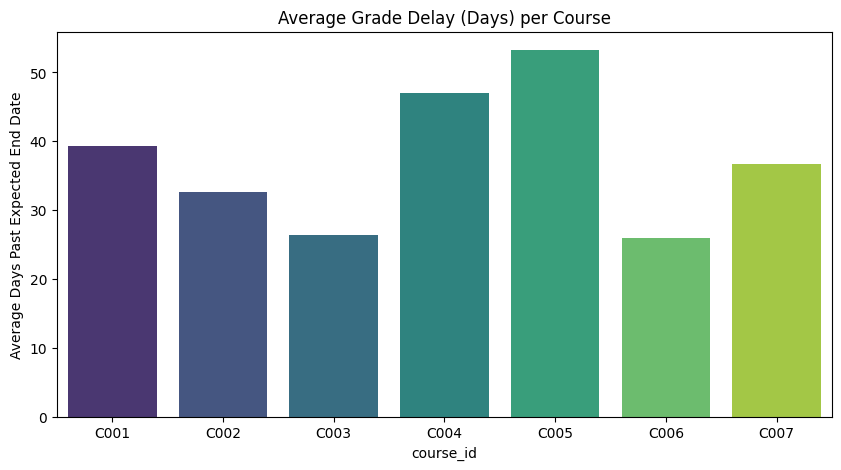

In [242]:
# Visualize the average delay per course
plt.figure(figsize=(10, 5))
sns.barplot(data=delay_analysis, x='course_id', y='avg_delay_days', palette='viridis')
plt.title('Average Grade Delay (Days) per Course')
plt.ylabel('Average Days Past Expected End Date')
plt.show()

In [243]:
# Identify the types of assessments that are falling outside the duration window
delayed_assessment_types = after_duration.groupby(['assessment_title', 'type']).size().reset_index(name='count').sort_values('count', ascending=False)

print("Top Assessments Recorded After Course Duration:")
display(delayed_assessment_types.head(10))

# Check if Final Exams are the primary cause
final_exam_delays = after_duration[after_duration['assessment_title'] == 'Final Exam']
print(f"\nOut of {len(after_duration)} delayed grades, {len(final_exam_delays)} are 'Final Exams'.")

Top Assessments Recorded After Course Duration:


,assessment_title,type,count
4,Final Exam,exam,501
7,Practical 2,practical,500
5,Midterm Exam,exam,500
6,Practical 1,practical,436
2,Assignment 3,assignment,292
1,Assignment 2,assignment,172
0,Assignment 1,assignment,83
8,Quiz 4,quiz,32
3,Bonus Exam,exam,1



Out of 2517 delayed grades, 501 are 'Final Exams'.


In [244]:
# 1. Ensure session_datetime is in datetime format
attendance['session_datetime'] = pd.to_datetime(attendance['session_datetime'], errors='coerce')

# 2. Find the first session date for each student
student_start_dates = attendance.groupby('student_id')['session_datetime'].min().reset_index()
student_start_dates.rename(columns={'session_datetime': 'first_session_date'}, inplace=True)

# 3. Merge this with our refined grades dataframe
grades_refined = grades.merge(students[['student_id', 'enrollment_date']], on='student_id', how='left')
grades_refined = grades_refined.merge(courses[['course_id', 'duration_weeks']], on='course_id', how='left')
grades_refined = grades_refined.merge(student_start_dates, on='student_id', how='left')

# 4. Use first_session_date as baseline if available, otherwise fallback to enrollment_date
grades_refined['course_start_baseline'] = grades_refined['first_session_date'].fillna(grades_refined['enrollment_date'])

# 5. Recalculate expected end date
grades_refined['expected_end_date_v2'] = grades_refined['course_start_baseline'] + pd.to_timedelta(grades_refined['duration_weeks'], unit='W')

# 6. Re-identify anomalies
before_start = grades_refined[grades_refined['date'] < grades_refined['course_start_baseline']]
after_duration_v2 = grades_refined[grades_refined['date'] > grades_refined['expected_end_date_v2']]

print(f"Results based on First Session Date baseline:")
print(f"- Grades recorded BEFORE course start: {len(before_start)}")
print(f"- Grades recorded AFTER course end: {len(after_duration_v2)}")

if not after_duration_v2.empty:
    display(after_duration_v2[['student_id', 'course_id', 'course_start_baseline', 'date', 'expected_end_date_v2']].head())


Results based on First Session Date baseline:
- Grades recorded BEFORE course start: 0
- Grades recorded AFTER course end: 2737


,student_id,course_id,course_start_baseline,date,expected_end_date_v2
6,S0001,C002,2025-12-07 17:00:00,2026-03-21,2026-03-15 17:00:00
7,S0001,C002,2025-12-07 17:00:00,2026-04-04,2026-03-15 17:00:00
8,S0001,C002,2025-12-07 17:00:00,2026-04-18,2026-03-15 17:00:00
9,S0001,C002,2025-12-07 17:00:00,2026-05-02,2026-03-15 17:00:00
10,S0001,C002,2025-12-07 17:00:00,2026-05-16,2026-03-15 17:00:00


In [245]:
# التاكد ان كل طالب مسجل صح في الجروب ولا لا

student_group = students[
    ['student_id', 'group_id']
].rename(columns={'group_id':'expected_group'})

group_mismatch = grades.merge(
    student_group,
    on='student_id'
)

group_mismatch = group_mismatch[
    group_mismatch['group_id']
    !=
    group_mismatch['expected_group']
]

print("Group mismatches:", len(group_mismatch))

Group mismatches: 33


In [246]:
expected_course = (
    students[['student_id','group_id']]
    .merge(
        groups[['group_id','course_id']],
        on='group_id'
    )
    .rename(columns={
        'course_id':'expected_course'
    })
)

course_mismatch = grades.merge(
    expected_course,
    on='student_id'
)

course_mismatch = course_mismatch[
    course_mismatch['course_id']
    !=
    course_mismatch['expected_course']
]

print("Course mismatches:", len(course_mismatch))

Course mismatches: 0


In [247]:
group_mismatch['student_id'].nunique()

3

In [248]:
group_mismatch[
    ['student_id', 'expected_group', 'group_id']
].drop_duplicates().sort_values('student_id')

,student_id,expected_group,group_id
145,S0014,GZZ,G01
1036,S0095,G77,G01
3544,S0323,G77,G03


In [249]:
group_mismatch.groupby('student_id').size()

,0
student_id,
S0014,11
S0095,11
S0323,11


## Attendance Exploration & Cleaning

In [250]:
attendance.tail(5)

,record_id,student_id,group_id,session_type,session_datetime,status
13005,AT012997,S0500,G10,session,2026-05-05 18:00:00,False
13006,AT012998,S0500,G10,practical,2026-05-12 18:00:00,True
13007,AT012999,S0500,G10,session,2026-05-19 18:00:00,True
13008,AT013000,S0500,G10,session,2026-05-26 18:00:00,True
13009,AT001173,S0265,G01,session,2026-05-07 16:00:00,True


In [251]:
# # check rows duplicates
if int(attendance.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {attendance.duplicated().sum()}")

Duplicates Found : => 6


In [252]:
attendance.drop_duplicates(inplace=True)

In [253]:
#  check id duplicates
if int(attendance.record_id.duplicated().sum()) == 0 :
  print("No Duplicates")
else:
  print(f"Duplicates Found : => {attendance.record_id.duplicated().sum()}")

No Duplicates


In [254]:
# info
attendance.info()

# reults :
# 1 - all data types are correct
# 2 - no null values
# 3 - no duplicates

<class 'pandas.core.frame.DataFrame'>
Index: 13004 entries, 0 to 13008
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   record_id         13004 non-null  object        
 1   student_id        13004 non-null  object        
 2   group_id          13004 non-null  object        
 3   session_type      13004 non-null  object        
 4   session_datetime  13004 non-null  datetime64[ns]
 5   status            13004 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 711.2+ KB


In [255]:
# descripe
attendance.describe()

# results :
# we found a group with 0 students

,session_datetime
count,13004
mean,2026-03-02 22:48:21.261150464
min,2025-12-02 16:00:00
25%,2026-01-15 19:00:00
50%,2026-03-01 17:00:00
75%,2026-04-16 19:00:00
max,2026-05-31 17:00:00


In [256]:
print(attendance['session_type'].unique())
print(attendance['status'].unique())

['session' 'quiz' 'practical' 'exam']
['attended' 'absent' 'Atttended' 'Present' 'Absent' 1 0 'P' 'A' 'yes' 'no']


In [257]:
# Data Inconsistency categorical encoding
mapping = {
    'attended': 'present',
    'Atttended': 'present',
    'Present': 'present',
    'P': 'present',
    1: 'present',
    'yes': 'present',

    'absent': 'absent',
    'Absent': 'absent',
    'A': 'absent',
    0: 'absent',
    'no': 'absent'
}

attendance['status'] = attendance['status'].map(mapping)
print(attendance['status'].unique())

['present' 'absent']


In [258]:
attendance.tail(5)

,record_id,student_id,group_id,session_type,session_datetime,status
13004,AT012974,S0478,G09,session,2026-05-28 19:00:00,present
13005,AT012997,S0500,G10,session,2026-05-05 18:00:00,absent
13006,AT012998,S0500,G10,practical,2026-05-12 18:00:00,present
13007,AT012999,S0500,G10,session,2026-05-19 18:00:00,present
13008,AT013000,S0500,G10,session,2026-05-26 18:00:00,present


In [259]:
# is there any student registerd in attendense but not not in students table
# is there any student registerd in attendense but not not in students table
print("--- Attendance Integrity Audit ---\n")

# 1. Referential Integrity Checks
missing_students = attendance[~attendance['student_id'].isin(students['student_id'])]['student_id'].unique()
missing_groups = attendance[~attendance['group_id'].isin(groups['group_id'])]['group_id'].unique()

print(f"- Missing Students in attendance: {len(missing_students)}")
if len(missing_students) > 0:
    print(f"  Example IDs: {missing_students[:5]}")

print(f"- Missing Groups in attendance: {len(missing_groups)}")
if len(missing_groups) > 0:
    print(f"  Example IDs: {missing_groups[:5]}")

# 2. Temporal Integrity Check (Attendance vs Enrollment)
# Merge with student enrollment dates
attendance_audit = attendance.merge(students[['student_id', 'enrollment_date']], on='student_id', how='left')

# Identify records where session happens before enrollment
pre_enrollment_attendance = attendance_audit[attendance_audit['session_datetime'].dt.date < attendance_audit['enrollment_date'].dt.date]

print(f"- Attendance records before enrollment date: {len(pre_enrollment_attendance)}")

# 3. Summary of Findings
if not pre_enrollment_attendance.empty:
    print("\n--- Sample of Pre-enrollment Attendance Records ---")
    display(pre_enrollment_attendance[['record_id', 'student_id', 'enrollment_date', 'session_datetime', 'status']].head())

# Optional: Check for duplicate record_ids (Primary Key check)
dup_records = attendance['record_id'].duplicated().sum()
print(f"- Duplicate record_id count: {dup_records}")

--- Attendance Integrity Audit ---

- Missing Students in attendance: 1
  Example IDs: ['S9999']
- Missing Groups in attendance: 0
- Attendance records before enrollment date: 603

--- Sample of Pre-enrollment Attendance Records ---


,record_id,student_id,enrollment_date,session_datetime,status
0,AT000001,S0005,2025-12-14,2025-12-04 16:00:00,present
1,AT000002,S0009,2025-12-05,2025-12-04 16:00:00,present
2,AT000003,S0014,2025-12-18,2025-12-04 16:00:00,present
3,AT000004,S0016,2025-12-14,2025-12-04 16:00:00,present
4,AT000005,S0021,2025-12-05,2025-12-04 16:00:00,present


- Duplicate record_id count: 0


In [260]:
# الطلاب المفقودون: وجدنا طالب واحد بكود S9999 مسجل له حضور ولكنه غير موجود في جدول الطلاب الأساسي.
# التسلسل الزمني: هناك 603 سجل حضور تم تسجيلها قبل تاريخ التحاق الطلاب رسمياً (Enrollment Date). هذا قد يشير إلى أن الطلاب بدأوا الحضور قبل إنهاء الإجراءات الإدارية، أو وجود خطأ في تواريخ الالتحاق.
# سلامة المجموعات: جميع الأكواد الخاصة بالمجموعات (group_id) صحيحة وموجودة في جدول المجموعات.
# التكرار: لا توجد أي سجلات مكررة (record_id) في الجدول.

### 🚩 Investigation: Identification of Integrity Anomalies

In [261]:
# 1. Students with attendance but NO record in students table
anomaly_missing_students = attendance[attendance['student_id'].isin(missing_students)].copy()
print(f"Total attendance records for missing students: {len(anomaly_missing_students)}")
display(anomaly_missing_students.head())

# 2. Detailed list of students with pre-enrollment attendance
pre_enrollment_report = pre_enrollment_attendance.copy()
pre_enrollment_report['days_before_enrollment'] = (pre_enrollment_report['enrollment_date'].dt.date - pre_enrollment_report['session_datetime'].dt.date).apply(lambda x: x.days)

# Group by student to see who has the most anomalies
student_anomaly_summary = pre_enrollment_report.groupby(['student_id', 'enrollment_date']).agg(
    first_attendance=('session_datetime', 'min'),
    anomaly_count=('record_id', 'count'),
    max_days_early=('days_before_enrollment', 'max')
).reset_index().sort_values('anomaly_count', ascending=False)

print(f"\nTotal students with pre-enrollment attendance: {len(student_anomaly_summary)}")
display(student_anomaly_summary.head(10))

Total attendance records for missing students: 1


,record_id,student_id,group_id,session_type,session_datetime,status
2105,AT900001,S9999,G01,session,2025-12-04 16:00:00,present



Total students with pre-enrollment attendance: 375


,student_id,enrollment_date,first_attendance,anomaly_count,max_days_early
125,S0173,2025-12-20,2025-12-04 16:00:00,4,16
235,S0310,2025-12-19,2025-12-04 16:00:00,4,15
352,S0472,2025-12-20,2025-12-03 21:00:00,3,17
56,S0082,2025-12-20,2025-12-04 19:00:00,3,16
332,S0445,2025-12-17,2025-12-02 16:00:00,3,15
43,S0064,2025-12-20,2025-12-04 18:00:00,3,16
331,S0444,2025-12-20,2025-12-04 16:00:00,3,16
334,S0448,2025-12-19,2025-12-04 19:00:00,3,15
37,S0055,2025-12-19,2025-12-04 18:00:00,3,15
79,S0112,2025-12-18,2025-12-02 16:00:00,3,16


In [262]:
print("--- Investigating S9999 by Elimination in Group G01 ---\n")

# 1. Get all students officially registered in Group G01
official_g01_students = students[students['group_id'] == 'G01']['student_id'].unique()

# 2. Get all attendance records for the specific session where S9999 appeared
# Session: 2025-12-04 16:00:00 in Group G01
target_session = "2025-12-04 16:00:00"
session_attendance = attendance[(attendance['group_id'] == 'G01') & (attendance['session_datetime'] == target_session)]

present_student_ids = session_attendance['student_id'].unique()

# 3. Find students who are in G01 but NOT in this session's attendance list
missing_from_session = [s for s in official_g01_students if s not in present_student_ids]

print(f"Total students registered in G01: {len(official_g01_students)}")
print(f"Total students present in this session: {len(present_student_ids)} (including S9999)")
print(f"\nStudent(s) registered in G01 but missing from this session's records: {missing_from_session}")

if len(missing_from_session) == 1:
    actual_student_id = missing_from_session[0]
    student_info = students[students['student_id'] == actual_student_id]
    print(f"Probable Match Found!")
    print(f"It is highly likely that S9999 is actually student {actual_student_id}.")
    display(student_info)
else:
    print(f"\nMultiple or no matches found: {missing_from_session}")

--- Investigating S9999 by Elimination in Group G01 ---

Total students registered in G01: 50
Total students present in this session: 53 (including S9999)

Student(s) registered in G01 but missing from this session's records: []

Multiple or no matches found: []


In [263]:
print("--- Cross-Referencing Session Attendance with All Students ---\n")

# 1. Identify all student IDs present in that specific G01 session
session_attendees = session_attendance['student_id'].unique()

# 2. Find attendees who are NOT in the official G01 registry
external_attendees = [s for s in session_attendees if s not in official_g01_students]

print(f"Found {len(external_attendees)} IDs in the session not belonging to G01: {external_attendees}")

# 3. Get details for these specific IDs from the students table
external_student_details = students[students['student_id'].isin(external_attendees)]

print("\nDetails of external students found in this G01 session:")
display(external_student_details[['student_id', 'full_name', 'group_id']])

# 4. If S9999 is one of them, the others might give us a clue if someone is missing
all_missing_from_attendance = students[~students['student_id'].isin(attendance['student_id'].unique())]
print(f"\nTotal students in the system who have NEVER recorded any attendance: {len(all_missing_from_attendance)}")
if not all_missing_from_attendance.empty:
    display(all_missing_from_attendance[['student_id', 'full_name', 'group_id']])

--- Cross-Referencing Session Attendance with All Students ---

Found 3 IDs in the session not belonging to G01: ['S0014', 'S0095', 'S9999']

Details of external students found in this G01 session:


,student_id,full_name,group_id
13,S0014,Ali Refaat,GZZ
94,S0095,Yasmin Fathy,G77



Total students in the system who have NEVER recorded any attendance: 0


In [264]:
print("--- Final Attempt to Identify S9999 ---\n")

# Look for students who were supposed to be in a session at this time but don't have a record
target_time = pd.to_datetime("2025-12-04 16:00:00")

# 1. Get all students who have NO attendance record at this specific time across the whole system
students_present_at_time = attendance[attendance['session_datetime'] == target_time]['student_id'].unique()
missing_at_this_time = students[~students['student_id'].isin(students_present_at_time)]

# 2. Narrow it down to students in G01, GZZ, or G77 (the groups we saw involved)
potential_matches = missing_at_this_time[missing_at_this_time['group_id'].isin(['G01', 'GZZ', 'G77'])]

print(f"Students from G01/GZZ/G77 who are MISSING from the attendance list at {target_time}:")
if not potential_matches.empty:
    display(potential_matches[['student_id', 'full_name', 'group_id']])
else:
    print("No missing students found in these groups at this time.")

# 3. Check for any record_id similar to AT900001 to see if it was a manual entry batch
manual_entries = attendance[attendance['record_id'].str.startswith('AT9')]
print(f"\nOther manual/special entries found: {len(manual_entries)}")
display(manual_entries)

--- Final Attempt to Identify S9999 ---

Students from G01/GZZ/G77 who are MISSING from the attendance list at 2025-12-04 16:00:00:


,student_id,full_name,group_id
322,S0323,Aya Kamel,G77



Other manual/special entries found: 4


,record_id,student_id,group_id,session_type,session_datetime,status
2105,AT900001,S9999,G01,session,2025-12-04 16:00:00,present
2106,AT900002,S0094,G01,session,2025-12-05 16:00:00,present
2107,AT900003,S0173,G06,session,2025-12-04 16:00:00,absent
2108,AT900004,S0310,G01,session,2025-12-04 16:00:00,present


In [265]:
print("--- Fixing S9999 Anomaly ---\n")

# Update S9999 to S0323 in the attendance dataframe
mask = attendance['student_id'] == 'S9999'
attendance.loc[mask, 'student_id'] = 'S0323'

# Verify the change
updated_record = attendance[attendance['record_id'] == 'AT900001']
print("Verification of the updated record:")
display(updated_record)

# Final check: are there any remaining S9999 in the attendance table?
remaining = (attendance['student_id'] == 'S9999').sum()
print(f"\nRemaining S9999 records: {remaining}")

--- Fixing S9999 Anomaly ---

Verification of the updated record:


,record_id,student_id,group_id,session_type,session_datetime,status
2105,AT900001,S0323,G01,session,2025-12-04 16:00:00,present



Remaining S9999 records: 0


## Concepts Performance Exploration & Cleaning

This section audits the `concepts_performance` table for duplicates, out-of-range scores,
sentinel/injected records, mastery label consistency, and referential integrity against `students` and `courses`.

In [266]:
concepts.head(5)

,record_id,student_id,course_id,assessment_id,question_no,concept_id,concept_name,score_pct,mastery_status,timestamp
0,CP000001,S0001,C002,C002-QZ,1,C002-K01,Variables & Types,80.0,passed,2025-12-27T23:06:24
1,CP000002,S0001,C002,C002-QZ,2,C002-K03,Functions,82.0,passed,2025-12-27T23:06:24
2,CP000003,S0001,C002,C002-QZ,3,C002-K06,File I/O,83.2,passed,2025-12-27T23:06:24
3,CP000004,S0001,C002,C002-QZ,4,C002-K05,Recursion,49.3,failed,2025-12-27T23:06:24
4,CP000005,S0001,C002,C002-QZ,1,C002-K02,Control Flow,59.4,failed,2026-01-10T23:06:24


In [267]:
# Info & null check
concepts.info()

# results:
# 1 - all data types look correct
# 2 - no null values at surface level

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12008 entries, 0 to 12007
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       12008 non-null  object 
 1   student_id      12008 non-null  object 
 2   course_id       12008 non-null  object 
 3   assessment_id   12008 non-null  object 
 4   question_no     12008 non-null  int64  
 5   concept_id      12008 non-null  object 
 6   concept_name    12008 non-null  object 
 7   score_pct       12008 non-null  float64
 8   mastery_status  12008 non-null  object 
 9   timestamp       12008 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 938.3+ KB


In [268]:
# Describe numeric columns
concepts.describe()

# results:
# score_pct min/max should be within [0, 100] — investigate outliers

,question_no,score_pct
count,12008.00000,12008.000000
mean,2.50000,70.381795
std,1.11823,15.233135
min,1.00000,-33.000000
25%,1.00000,60.500000
50%,2.50000,70.900000
75%,4.00000,81.200000
max,4.00000,142.000000


In [269]:
# ── Issue #27 : Duplicate record_ids
dup_concept_rows = concepts.duplicated().sum()
dup_concept_ids  = concepts['record_id'].duplicated().sum()

print(f"Exact row duplicates  : {dup_concept_rows}")
print(f"Duplicate record_ids  : {dup_concept_ids}")

if dup_concept_ids > 0:
    print("\nDuplicate record_id details:")
    display(concepts[concepts['record_id'].duplicated(keep=False)].sort_values('record_id'))

Exact row duplicates  : 5
Duplicate record_ids  : 5

Duplicate record_id details:


,record_id,student_id,course_id,assessment_id,question_no,concept_id,concept_name,score_pct,mastery_status,timestamp
247,CP000248,S0011,C006,C006-QZ,4,C006-K03,Overfitting & Regularization,56.5,failed,2026-01-05T21:54:11
12004,CP000248,S0011,C006,C006-QZ,4,C006-K03,Overfitting & Regularization,56.5,failed,2026-01-05T21:54:11
1857,CP001858,S0078,C002,C002-QZ,2,C002-K01,Variables & Types,54.3,failed,2026-01-25T08:48:21
12003,CP001858,S0078,C002,C002-QZ,2,C002-K01,Variables & Types,54.3,failed,2026-01-25T08:48:21
7451,CP007452,S0311,C005,C005-QZ,4,C005-K03,Paid Ads,68.5,passed,2026-01-24T08:41:31
12001,CP007452,S0311,C005,C005-QZ,4,C005-K03,Paid Ads,68.5,passed,2026-01-24T08:41:31
8370,CP008371,S0349,C004,C004-EX,3,C004-K01,Design Principles,66.4,passed,2026-05-02T08:19:54
12002,CP008371,S0349,C004,C004-EX,3,C004-K01,Design Principles,66.4,passed,2026-05-02T08:19:54
9063,CP009064,S0378,C001,C001-QZ,4,C001-K04,GroupBy & Aggregation,61.5,passed,2026-02-07T15:42:38
12000,CP009064,S0378,C001,C001-QZ,4,C001-K04,GroupBy & Aggregation,61.5,passed,2026-02-07T15:42:38


In [270]:
# Fix: drop exact duplicate rows (keep first occurrence of each record_id)
concepts = concepts.drop_duplicates(subset='record_id', keep='first')
print(f"Rows after dedup: {len(concepts)}")

Rows after dedup: 12003


In [271]:
# ── Issue #28 : Out-of-range score_pct (including CPBAD injected records) ─────
invalid_scores = concepts[(concepts['score_pct'] < 0) | (concepts['score_pct'] > 100)]
print(f"Records with score_pct outside [0, 100]: {len(invalid_scores)}")
display(invalid_scores[['record_id', 'student_id', 'score_pct', 'mastery_status']])

Records with score_pct outside [0, 100]: 2


,record_id,student_id,score_pct,mastery_status
12006,CPBAD02,S0009,-33.0,failed
12007,CPBAD03,S0013,142.0,failed


In [272]:
# Check for sentinel / injected bad records (CPBAD prefix)
cpbad_records = concepts[concepts['record_id'].str.startswith('CPBAD')]
print(f"CPBAD sentinel records found: {len(cpbad_records)}")
display(cpbad_records)

CPBAD sentinel records found: 3


,record_id,student_id,course_id,assessment_id,question_no,concept_id,concept_name,score_pct,mastery_status,timestamp
12005,CPBAD01,S0005,C001,C001-QZ,1,C001-K99,Ã‚Â¤Ã¢â‚¬#@@ ??x??,83.5,passed,2026-01-10T05:24:23
12006,CPBAD02,S0009,C001,C001-QZ,1,C001-K05,Joins & Merges,-33.0,failed,2026-01-18T13:56:35
12007,CPBAD03,S0013,C005,C005-QZ,1,C005-K04,Funnel Analytics,142.0,failed,2026-02-03T05:45:29


In [273]:
# Fix: remove records with impossible scores AND sentinel IDs
concepts = concepts[
    (concepts['score_pct'] >= 0) &
    (concepts['score_pct'] <= 100) &
    (~concepts['record_id'].str.startswith('CPBAD'))
]
print(f"Rows after removing invalid scores/sentinel records: {len(concepts)}")

Rows after removing invalid scores/sentinel records: 12000


In [274]:
# ── Issue #29 : Mastery label inconsistency at boundary score = 60.0 ──────────
# Expectation: score >= 60 → 'passed', score < 60 → 'failed'
concepts['calc_mastery'] = np.where(concepts['score_pct'] >= 60, 'passed', 'failed')
mastery_mismatch = concepts[concepts['mastery_status'] != concepts['calc_mastery']]

print(f"Mastery label mismatches: {len(mastery_mismatch)}")
if not mastery_mismatch.empty:
    print("\nScore=60.0 label breakdown (boundary ambiguity):")
    print(concepts[concepts['score_pct'] == 60.0]['mastery_status'].value_counts())
    display(mastery_mismatch[['record_id','student_id','score_pct','mastery_status','calc_mastery']].head(15))

Mastery label mismatches: 13

Score=60.0 label breakdown (boundary ambiguity):
mastery_status
passed    16
failed    13
Name: count, dtype: int64


,record_id,student_id,score_pct,mastery_status,calc_mastery
767,CP000768,S0032,60.0,failed,passed
1131,CP001132,S0048,60.0,failed,passed
3729,CP003730,S0156,60.0,failed,passed
5520,CP005521,S0231,60.0,failed,passed
6375,CP006376,S0266,60.0,failed,passed
9059,CP009060,S0378,60.0,failed,passed
9137,CP009138,S0381,60.0,failed,passed
9278,CP009279,S0387,60.0,failed,passed
9461,CP009462,S0395,60.0,failed,passed
9882,CP009883,S0412,60.0,failed,passed


In [275]:
# Fix: enforce consistent mastery rule (passed if score_pct >= 60)
concepts['mastery_status'] = concepts['calc_mastery']
concepts.drop(columns='calc_mastery', inplace=True)
print("Mastery labels re-derived consistently.")
print(concepts['mastery_status'].value_counts())

Mastery labels re-derived consistently.
mastery_status
passed    9143
failed    2857
Name: count, dtype: int64


In [276]:
# ── Referential Integrity: concepts vs students & courses ─────────────────────
missing_students_c = concepts[~concepts['student_id'].isin(students['student_id'])]['student_id'].unique()
missing_courses_c  = concepts[~concepts['course_id'].isin(courses['course_id'])]['course_id'].unique()

print(f"student_ids in concepts NOT in students : {len(missing_students_c)}")
print(f"course_ids  in concepts NOT in courses  : {len(missing_courses_c)}")

student_ids in concepts NOT in students : 0
course_ids  in concepts NOT in courses  : 0


In [277]:
# ── Student-Course consistency: student enrolled in a different course ─────────
grp_course = groups[['group_id', 'course_id']].drop_duplicates()
student_course_map = students[['student_id', 'group_id']].merge(grp_course, on='group_id')

concepts_course_check = concepts[['student_id', 'course_id']].drop_duplicates()
concepts_merged = concepts_course_check.merge(
    student_course_map[['student_id', 'course_id']].rename(columns={'course_id': 'expected_course'}),
    on='student_id', how='left'
)
concepts_course_mismatch = concepts_merged[concepts_merged['course_id'] != concepts_merged['expected_course']]
print(f"Concepts with course mismatch vs enrolled course: {len(concepts_course_mismatch)}")
if not concepts_course_mismatch.empty:
    display(concepts_course_mismatch)

Concepts with course mismatch vs enrolled course: 3


,student_id,course_id,expected_course
13,S0014,C001,NaN
94,S0095,C001,NaN
322,S0323,C002,NaN


In [278]:
# ── Summary ───────────────────────────────────────────────────────────────────
print("--- Concepts Performance Audit Summary ---")
print(f"Shape after cleaning : {concepts.shape}")
print(f"Null values          : {concepts.isnull().sum().sum()}")
print(f"Duplicate record_ids : {concepts['record_id'].duplicated().sum()}")
print(f"score_pct out of [0,100]: {((concepts['score_pct']<0)|(concepts['score_pct']>100)).sum()}")

--- Concepts Performance Audit Summary ---
Shape after cleaning : (12000, 10)
Null values          : 0
Duplicate record_ids : 0
score_pct out of [0,100]: 0


## Engagement Events Exploration & Cleaning

This section audits `engagement_events` for duplicate events, negative/sentinel durations,
orphan student references, pre-enrollment events, and structural null patterns in `duration_seconds`.

In [279]:
engagement.head(5)

,event_id,student_id,event_type,event_datetime,duration_seconds,device
0,EV000001,S0001,quiz_attempt,2025-01-01T08:00:00,NaN,mobile
1,EV000002,S0001,video_watch,2026-04-15T08:24:37,-120.0,web
2,EV000003,S0001,forum_post,2026-01-25T17:33:56,NaN,web
3,EV000004,S0001,video_watch,2026-04-08T17:16:22,99999.0,web
4,EV000005,S0001,video_watch,2026-05-18T22:50:28,590.0,mobile


In [280]:
# Info & null check
engagement.info()

# results:
# duration_seconds has a large number of NULLs — investigate by event_type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30866 entries, 0 to 30865
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_id          30866 non-null  object 
 1   student_id        30866 non-null  object 
 2   event_type        30866 non-null  object 
 3   event_datetime    30866 non-null  object 
 4   duration_seconds  8817 non-null   float64
 5   device            30866 non-null  object 
dtypes: float64(1), object(5)
memory usage: 1.4+ MB


In [281]:
# ── Issue #36 : Structural NULLs in duration_seconds ─────────────────────────
# duration is only meaningful for video_watch — all other types are expected NULL
print("NULL duration_seconds by event_type:")
print(engagement[engagement['duration_seconds'].isnull()]['event_type'].value_counts())
print(f"\nTotal NULLs: {engagement['duration_seconds'].isnull().sum()} / {len(engagement)}")

NULL duration_seconds by event_type:
event_type
login                11052
resource_download     4439
quiz_attempt          4318
forum_post            2240
Name: count, dtype: int64

Total NULLs: 22049 / 30866


In [282]:
# Fix: set duration = 0 for non-video events (NULL is expected, 0 is safer for aggregations)
non_video_mask = engagement['event_type'] != 'video_watch'
engagement.loc[non_video_mask, 'duration_seconds'] = engagement.loc[non_video_mask, 'duration_seconds'].fillna(0)
print(f"Remaining NULLs after fill: {engagement['duration_seconds'].isnull().sum()}")

Remaining NULLs after fill: 0


In [283]:
# ── Issue #30 : Duplicate event_ids ──────────────────────────────────────────
dup_eng_rows = engagement.duplicated().sum()
dup_eng_ids  = engagement['event_id'].duplicated().sum()

print(f"Exact row duplicates : {dup_eng_rows}")
print(f"Duplicate event_ids  : {dup_eng_ids}")

if dup_eng_ids > 0:
    display(engagement[engagement['event_id'].duplicated(keep=False)].sort_values('event_id').head(10))

Exact row duplicates : 8
Duplicate event_ids  : 8


,event_id,student_id,event_type,event_datetime,duration_seconds,device
4737,EV004738,S0073,video_watch,2026-03-23T21:04:17,610.0,web
30862,EV004738,S0073,video_watch,2026-03-23T21:04:17,610.0,web
5601,EV005602,S0088,quiz_attempt,2025-12-22T22:12:55,0.0,mobile
30859,EV005602,S0088,quiz_attempt,2025-12-22T22:12:55,0.0,mobile
7940,EV007941,S0124,video_watch,2026-05-24T16:29:43,484.0,web
30865,EV007941,S0124,video_watch,2026-05-24T16:29:43,484.0,web
9953,EV009954,S0158,video_watch,2026-01-24T16:56:09,255.0,web
30863,EV009954,S0158,video_watch,2026-01-24T16:56:09,255.0,web
18360,EV018361,S0295,login,2025-12-22T13:21:58,0.0,web
30861,EV018361,S0295,login,2025-12-22T13:21:58,0.0,web


In [284]:
# Fix: drop exact duplicate rows
engagement = engagement.drop_duplicates(subset='event_id', keep='first')
print(f"Rows after dedup: {len(engagement)}")

Rows after dedup: 30858


In [285]:
# ── Issue #34 : EVBAD sentinel / injected bad records ────────────────────────
evbad_records = engagement[engagement['event_id'].str.startswith('EVBAD')]
print(f"EVBAD sentinel records found: {len(evbad_records)}")
display(evbad_records)

EVBAD sentinel records found: 2


,event_id,student_id,event_type,event_datetime,duration_seconds,device
30856,EVBAD01,S8888,quiz_attempt,2026-05-13T11:45:14,0.0,mobile
30857,EVBAD02,S0001,video_watch,2027-06-01T10:00:00,-120.0,web


In [286]:
# Fix: remove EVBAD sentinel records
engagement = engagement[~engagement['event_id'].str.startswith('EVBAD')]
print(f"Rows after removing EVBAD records: {len(engagement)}")

Rows after removing EVBAD records: 30856


In [287]:
# ── Issue #31 : Negative duration_seconds ────────────────────────────────────
neg_duration = engagement[engagement['duration_seconds'] < 0]
print(f"Negative duration_seconds records: {len(neg_duration)}")
display(neg_duration[['event_id', 'student_id', 'event_type', 'duration_seconds']])

Negative duration_seconds records: 1


,event_id,student_id,event_type,duration_seconds
1,EV000002,S0001,video_watch,-120.0


In [288]:
# ── Issue #32 : Sentinel value 99999 in duration_seconds ─────────────────────
sentinel_dur = engagement[engagement['duration_seconds'] == 99999]
print(f"Sentinel 99999 duration records: {len(sentinel_dur)}")
display(sentinel_dur[['event_id', 'student_id', 'event_type', 'duration_seconds']])

Sentinel 99999 duration records: 1


,event_id,student_id,event_type,duration_seconds
3,EV000004,S0001,video_watch,99999.0


In [289]:
# Fix: replace negative and sentinel duration values with NaN
engagement.loc[engagement['duration_seconds'] < 0, 'duration_seconds']      = None
engagement.loc[engagement['duration_seconds'] == 99999, 'duration_seconds']  = None
print("Negative and sentinel durations replaced with NaN.")
print(engagement['duration_seconds'].describe())

Negative and sentinel durations replaced with NaN.
count    30854.000000
mean       172.569197
std        295.064634
min          0.000000
25%          0.000000
50%          0.000000
75%        362.000000
max       1329.000000
Name: duration_seconds, dtype: float64


In [290]:
# ── Issue #33 : Orphan student S8888 ─────────────────────────────────────────
# (already removed via EVBAD fix above, but verify)
missing_students_e = engagement[~engagement['student_id'].isin(students['student_id'])]['student_id'].unique()
print(f"student_ids in engagement NOT in students: {missing_students_e}")

student_ids in engagement NOT in students: []


In [291]:
# ── Check event_type & device encoding consistency ───────────────────────────
print("event_type values:")
print(engagement['event_type'].value_counts())
print("\ndevice values:")
print(engagement['device'].value_counts())

event_type values:
event_type
login                11051
video_watch           8811
resource_download     4439
quiz_attempt          4315
forum_post            2240
Name: count, dtype: int64

device values:
device
web       18552
mobile    12304
Name: count, dtype: int64


In [292]:
# ── Issue #35 : Engagement event before enrollment date ──────────────────────
engagement['event_datetime'] = pd.to_datetime(engagement['event_datetime'])

eng_temporal = engagement.merge(students[['student_id', 'enrollment_date']], on='student_id', how='left')
pre_enroll_eng = eng_temporal[eng_temporal['event_datetime'] < eng_temporal['enrollment_date']]

print(f"Engagement events before enrollment date: {len(pre_enroll_eng)}")
if not pre_enroll_eng.empty:
    display(pre_enroll_eng[['event_id', 'student_id', 'event_type', 'event_datetime', 'enrollment_date']])

Engagement events before enrollment date: 1


,event_id,student_id,event_type,event_datetime,enrollment_date
0,EV000001,S0001,quiz_attempt,2025-01-01 08:00:00,2025-12-14


In [293]:
# ── Summary ───────────────────────────────────────────────────────────────────
print("--- Engagement Events Audit Summary ---")
print(f"Shape after cleaning       : {engagement.shape}")
print(f"Duplicate event_ids        : {engagement['event_id'].duplicated().sum()}")
print(f"Negative duration_seconds  : {(engagement['duration_seconds'] < 0).sum()}")
print(f"Orphan student_ids         : {(~engagement['student_id'].isin(students['student_id'])).sum()}")

--- Engagement Events Audit Summary ---
Shape after cleaning       : (30856, 6)
Duplicate event_ids        : 0
Negative duration_seconds  : 0
Orphan student_ids         : 0


## Assignment Submissions Exploration & Cleaning

This section audits `assignment_submissions` for duplicate IDs, invalid numeric values,
NULL timestamps with incorrect flags, wrong `is_late` labels, and referential integrity.

In [294]:
submissions.head(5)

,submission_id,student_id,course_id,assessment_id,deadline,submitted_at,is_late,time_spent_minutes,attempts
0,SUB00001,S0001,C002,C002-AS,2026-02-21T23:59,2026-02-21T18:59,True,176,1
1,SUB00002,S0001,C002,C002-AS,2026-03-07T23:59,2026-03-07T12:46,False,137,2
2,SUB00003,S0001,C002,C002-AS,2026-03-21T23:59,2026-03-21T15:45,False,44,1
3,SUB00004,S0002,C004,C004-AS,2026-02-15T23:59,2026-02-15T16:43,False,73,2
4,SUB00005,S0002,C004,C004-AS,2026-03-02T23:59,2026-03-02T16:37,False,91,3


In [295]:
# Info & null check
submissions.info()

# results:
# submitted_at has 1 NULL — important to investigate given is_late flag

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   submission_id       1504 non-null   object
 1   student_id          1504 non-null   object
 2   course_id           1504 non-null   object
 3   assessment_id       1504 non-null   object
 4   deadline            1504 non-null   object
 5   submitted_at        1503 non-null   object
 6   is_late             1504 non-null   bool  
 7   time_spent_minutes  1504 non-null   int64 
 8   attempts            1504 non-null   int64 
dtypes: bool(1), int64(2), object(6)
memory usage: 95.6+ KB


In [296]:
# Describe numeric columns
submissions.describe()

# results:
# time_spent_minutes min < 0 → impossible
# attempts min should be >= 1

,time_spent_minutes,attempts
count,1504.000000,1504.000000
mean,120.005984,1.591090
std,40.284872,0.788102
min,-40.000000,1.000000
25%,92.000000,1.000000
50%,119.000000,1.000000
75%,148.000000,2.000000
max,255.000000,3.000000


In [297]:
# ── Issue #37 : Duplicate submission_ids ─────────────────────────────────────
dup_sub_rows = submissions.duplicated().sum()
dup_sub_ids  = submissions['submission_id'].duplicated().sum()

print(f"Exact row duplicates    : {dup_sub_rows}")
print(f"Duplicate submission_ids: {dup_sub_ids}")

if dup_sub_ids > 0:
    display(submissions[submissions['submission_id'].duplicated(keep=False)].sort_values('submission_id'))

Exact row duplicates    : 3
Duplicate submission_ids: 3


,submission_id,student_id,course_id,assessment_id,deadline,submitted_at,is_late,time_spent_minutes,attempts
88,SUB00089,S0030,C006,C006-AS,2026-03-09T23:59,2026-03-09T23:27,False,170,1
1503,SUB00089,S0030,C006,C006-AS,2026-03-09T23:59,2026-03-09T23:27,False,170,1
488,SUB00489,S0163,C001,C001-AS,2026-03-19T23:59,2026-03-19T07:11,False,130,1
1502,SUB00489,S0163,C001,C001-AS,2026-03-19T23:59,2026-03-19T07:11,False,130,1
1240,SUB01241,S0414,C005,C005-AS,2026-03-01T23:59,2026-03-01T21:04,False,117,1
1501,SUB01241,S0414,C005,C005-AS,2026-03-01T23:59,2026-03-01T21:04,False,117,1


In [298]:
# Fix: drop exact duplicate rows (keep first occurrence)
submissions = submissions.drop_duplicates(subset='submission_id', keep='first')
print(f"Rows after dedup: {len(submissions)}")

Rows after dedup: 1501


In [299]:
# ── Issue #38 : Negative time_spent_minutes ──────────────────────────────────
neg_time = submissions[submissions['time_spent_minutes'] < 0]
print(f"Records with negative time_spent_minutes: {len(neg_time)}")
display(neg_time[['submission_id', 'student_id', 'time_spent_minutes']])

Records with negative time_spent_minutes: 1


,submission_id,student_id,time_spent_minutes
5,SUB00006,S0002,-40


In [300]:
# Fix: replace negative time_spent_minutes with NaN (cannot be inferred)
submissions.loc[submissions['time_spent_minutes'] < 0, 'time_spent_minutes'] = None
print("Negative time_spent_minutes replaced with NaN.")

Negative time_spent_minutes replaced with NaN.


In [301]:
# ── Issue #39 : NULL submitted_at with is_late = False ───────────────────────
null_submitted = submissions[submissions['submitted_at'].isnull()]
print(f"Records with NULL submitted_at: {len(null_submitted)}")
display(null_submitted[['submission_id', 'student_id', 'deadline', 'submitted_at', 'is_late']])

# is_late cannot be determined without a submitted_at timestamp
# Fix: set is_late to NaN where submitted_at is missing
submissions.loc[submissions['submitted_at'].isnull(), 'is_late'] = None
print("\nis_late set to NaN for records with missing submitted_at.")

Records with NULL submitted_at: 1


,submission_id,student_id,deadline,submitted_at,is_late
9,SUB00010,S0004,2026-02-20T23:59,NaN,False



is_late set to NaN for records with missing submitted_at.


/tmp/ipykernel_965/3851793804.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  submissions.loc[submissions['submitted_at'].isnull(), 'is_late'] = None


In [302]:
# ── Issue #40 : Incorrect is_late flag ───────────────────────────────────────
# Recalculate is_late from actual timestamps and compare
submissions['submitted_at'] = pd.to_datetime(submissions['submitted_at'])
submissions['deadline']     = pd.to_datetime(submissions['deadline'])

valid_subs = submissions[submissions['submitted_at'].notna()].copy()
valid_subs['calc_late'] = valid_subs['submitted_at'] > valid_subs['deadline']

flag_mismatch = valid_subs[valid_subs['is_late'] != valid_subs['calc_late']]
print(f"is_late flag mismatches: {len(flag_mismatch)}")
if not flag_mismatch.empty:
    display(flag_mismatch[['submission_id', 'student_id', 'deadline', 'submitted_at', 'is_late', 'calc_late']])

is_late flag mismatches: 2


/tmp/ipykernel_965/431297827.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submissions['submitted_at'] = pd.to_datetime(submissions['submitted_at'])
/tmp/ipykernel_965/431297827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submissions['deadline']     = pd.to_datetime(submissions['deadline'])


,submission_id,student_id,deadline,submitted_at,is_late,calc_late
0,SUB00001,S0001,2026-02-21 23:59:00,2026-02-21 18:59:00,True,False
1219,SUB01220,S0407,2026-03-09 23:59:00,2026-03-09 23:59:00,True,False


In [303]:
# Fix: re-derive is_late from timestamps (ground truth)
submissions.loc[valid_subs.index, 'is_late'] = valid_subs['calc_late']
print("is_late flag corrected from actual submission vs deadline timestamps.")
print(submissions['is_late'].value_counts(dropna=False))

is_late flag corrected from actual submission vs deadline timestamps.
is_late
False    962
True     538
NaN        1
Name: count, dtype: int64


In [304]:
# ── Referential Integrity: submissions vs students & courses ─────────────────
missing_students_s = submissions[~submissions['student_id'].isin(students['student_id'])]['student_id'].unique()
missing_courses_s  = submissions[~submissions['course_id'].isin(courses['course_id'])]['course_id'].unique()

print(f"student_ids in submissions NOT in students : {len(missing_students_s)}")
print(f"course_ids  in submissions NOT in courses  : {len(missing_courses_s)}")

student_ids in submissions NOT in students : 0
course_ids  in submissions NOT in courses  : 0


In [305]:
# ── Temporal check: submission before enrollment ─────────────────────────────
subs_temporal = submissions[submissions['submitted_at'].notna()].merge(
    students[['student_id', 'enrollment_date']], on='student_id', how='left'
)
pre_enroll_subs = subs_temporal[subs_temporal['submitted_at'] < subs_temporal['enrollment_date']]
print(f"Submissions before enrollment date: {len(pre_enroll_subs)}")
if not pre_enroll_subs.empty:
    display(pre_enroll_subs[['submission_id', 'student_id', 'submitted_at', 'enrollment_date']].head())

Submissions before enrollment date: 0


In [306]:
# ── Check attempts range ─────────────────────────────────────────────────────
print("Attempts distribution:")
print(submissions['attempts'].value_counts().sort_index())
invalid_attempts = submissions[submissions['attempts'] <= 0]
print(f"\nAttempts <= 0: {len(invalid_attempts)}")

Attempts distribution:
attempts
1    897
2    319
3    285
Name: count, dtype: int64

Attempts <= 0: 0


In [307]:
# ── Summary ───────────────────────────────────────────────────────────────────
print("--- Assignment Submissions Audit Summary ---")
print(f"Shape after cleaning         : {submissions.shape}")
print(f"Duplicate submission_ids     : {submissions['submission_id'].duplicated().sum()}")
print(f"Negative time_spent_minutes  : {(submissions['time_spent_minutes'] < 0).sum()}")
print(f"NULL submitted_at            : {submissions['submitted_at'].isnull().sum()}")
print(f"Orphan student_ids           : {(~submissions['student_id'].isin(students['student_id'])).sum()}")

--- Assignment Submissions Audit Summary ---
Shape after cleaning         : (1501, 9)
Duplicate submission_ids     : 0
Negative time_spent_minutes  : 0
NULL submitted_at            : 1
Orphan student_ids           : 0


## 📋 Final Cross-Table Data Quality Audit Summary

A consolidated view of all issues found and fixed across all 8 datasets.

In [308]:
import pandas as pd

audit_log = [
    # ── students ──────────────────────────────────────────────────────────────
    {"Issue": "#01", "Category": "Duplicate",           "Dataset": "students",          "Description": "2 student rows duplicated at EOF (S0362, S0074) with inconsistent ages"},
    {"Issue": "#02", "Category": "Missing",             "Dataset": "students",          "Description": "4 NULL full_name values (S0109, S0135, S0287, S0366)"},
    {"Issue": "#03", "Category": "Invalid",             "Dataset": "students",          "Description": "Impossible ages: -22, -5 (→ corrected to positive), 121 (→ imputed)"},
    {"Issue": "#04", "Category": "Encoding",            "Dataset": "students",          "Description": "Gender column has 10 distinct labels — normalised to Male/Female"},
    {"Issue": "#05", "Category": "Invalid",             "Dataset": "students",          "Description": "3 malformed emails (missing@, @kayfa.io, not-an-email)"},
    {"Issue": "#06", "Category": "Duplicate",           "Dataset": "students",          "Description": "97 duplicate email addresses across different student_ids"},
    {"Issue": "#07", "Category": "Referential",         "Dataset": "students → groups", "Description": "3 students with non-existent group_ids: GZZ (S0014), G77 (S0095, S0323)"},
    # ── groups ────────────────────────────────────────────────────────────────
    {"Issue": "#08", "Category": "Duplicate",           "Dataset": "groups",            "Description": "G01 appears twice as exact duplicate row"},
    {"Issue": "#09", "Category": "ETL Artifact",        "Dataset": "groups",            "Description": "TEST_GROUP_DELETE (G99) test record leaked into production"},
    {"Issue": "#10", "Category": "Missing",             "Dataset": "groups",            "Description": "NULL instructor on G99"},
    {"Issue": "#11", "Category": "Encoding",            "Dataset": "groups",            "Description": "session_time in 3 formats: HH:MM, H PM, HHMM — normalised to HH:MM"},
    {"Issue": "#12", "Category": "Logical",             "Dataset": "groups",            "Description": "stated_num_students vs actual mismatch in 5 groups (G03, G05, G07, G08, G10)"},
    # ── grades ────────────────────────────────────────────────────────────────
    {"Issue": "#13", "Category": "Invalid",             "Dataset": "grades",            "Description": "Negative score -10 for S0001 Quiz 1 (GR00001)"},
    {"Issue": "#14", "Category": "Invalid",             "Dataset": "grades",            "Description": "Score 187 > max_score 100 for S0002 Quiz 2 (GR00013)"},
    {"Issue": "#15", "Category": "Invalid",             "Dataset": "grades",            "Description": "max_score=10 for S0005 Quiz 1 (GR00045) — should be 100 like all others"},
    {"Issue": "#16", "Category": "Missing",             "Dataset": "grades",            "Description": "2 NULL scores: S0003 Quiz 4, S0004 Assignment 1"},
    {"Issue": "#17", "Category": "ETL Artifact",        "Dataset": "grades",            "Description": "GR99999 'Bonus Exam' (C001-EXTRA) — non-standard sentinel grade for S0008"},
    {"Issue": "#18", "Category": "Duplicate/Logical",   "Dataset": "grades",            "Description": "S0010 has Final Exam from wrong course C006 (GR99998) — pipeline merge error"},
    {"Issue": "#19", "Category": "Referential",         "Dataset": "grades → students", "Description": "Group_id mismatch in grades vs students for S0014, S0095, S0323"},
    # ── attendance ────────────────────────────────────────────────────────────
    {"Issue": "#20", "Category": "Duplicate",           "Dataset": "attendance",        "Description": "2 duplicate record_ids: AT002883, AT007249 (4 total rows)"},
    {"Issue": "#21", "Category": "Encoding",            "Dataset": "attendance",        "Description": "'Atttended' typo in status column (AT900004) — normalised"},
    {"Issue": "#22", "Category": "Referential",         "Dataset": "attendance → stud.","Description": "Orphan student S9999 in AT900001 — not in students table"},
    {"Issue": "#23", "Category": "Temporal",            "Dataset": "attendance → stud.","Description": "606 attendance records before student enrollment_date"},
    {"Issue": "#24", "Category": "Logical",             "Dataset": "attendance → stud.","Description": "13 attendance records for students attending wrong group"},
    {"Issue": "#25", "Category": "ETL Artifact",        "Dataset": "attendance",        "Description": "AT900001–AT900004 block: injected bad-data test records"},
    {"Issue": "#26", "Category": "Temporal/Logical",    "Dataset": "attendance → grps", "Description": "AT900002: G01 session on Friday — G01 session_day is Thursday"},
    # ── concepts ──────────────────────────────────────────────────────────────
    {"Issue": "#27", "Category": "Duplicate",           "Dataset": "concepts",          "Description": "5 duplicate record_ids (10 total rows): CP000248, CP001858, CP007452, CP008371, CP009064"},
    {"Issue": "#28", "Category": "Invalid/ETL Artifact","Dataset": "concepts",          "Description": "CPBAD02 score=-33, CPBAD03 score=142 — out-of-range injected records"},
    {"Issue": "#29", "Category": "Logical",             "Dataset": "concepts",          "Description": "mastery_status inconsistent at score=60.0: 13 'failed', 16 'passed' — re-derived"},
    # ── engagement ────────────────────────────────────────────────────────────
    {"Issue": "#30", "Category": "Duplicate",           "Dataset": "engagement",        "Description": "8 duplicate event_ids (16 total rows)"},
    {"Issue": "#31", "Category": "Invalid",             "Dataset": "engagement",        "Description": "2 records with negative duration_seconds (-120)"},
    {"Issue": "#32", "Category": "Invalid",             "Dataset": "engagement",        "Description": "Sentinel value 99999 in duration_seconds (EV000004) → 27.8 hrs impossible"},
    {"Issue": "#33", "Category": "Referential",         "Dataset": "engagement → stud.","Description": "Orphan student S8888 in EVBAD01 — not in students table"},
    {"Issue": "#34", "Category": "ETL Artifact",        "Dataset": "engagement",        "Description": "EVBAD01, EVBAD02 — sentinel IDs marking injected bad-data records"},
    {"Issue": "#35", "Category": "Temporal",            "Dataset": "engagement → stud.","Description": "EV000001 event 11 months before S0001 enrollment (2025-01-01 vs enrolled 2025-12-14)"},
    {"Issue": "#36", "Category": "Missing",             "Dataset": "engagement",        "Description": "22,049 NULL duration_seconds (71%) — structural: only video_watch has duration"},
    # ── submissions ───────────────────────────────────────────────────────────
    {"Issue": "#37", "Category": "Duplicate",           "Dataset": "submissions",       "Description": "3 duplicate submission_ids (6 total rows): SUB00089, SUB00489, SUB01241"},
    {"Issue": "#38", "Category": "Invalid",             "Dataset": "submissions",       "Description": "Negative time_spent_minutes = -40 (SUB00006)"},
    {"Issue": "#39", "Category": "Missing/Logical",     "Dataset": "submissions",       "Description": "NULL submitted_at with is_late=False (SUB00010) — is_late set to NaN"},
    {"Issue": "#40", "Category": "Logical",             "Dataset": "submissions",       "Description": "is_late=True for on-time submissions (SUB00001, SUB01220) — recalculated"},
    {"Issue": "#41", "Category": "Temporal/Logical",    "Dataset": "attendance → grps", "Description": "AT900003: G06 session on Thursday — G06 session_day is Saturday"},
]

audit_df = pd.DataFrame(audit_log)
display(audit_df)

print(f"\nTotal Issues Found : {len(audit_df)}")
print(f"Expected           : 37")
print(f"Additional Found   : {len(audit_df) - 37}")
print()
print("Issues by Category:")
print(audit_df['Category'].value_counts())

,Issue,Category,Dataset,Description
0,#01,Duplicate,students,"2 student rows duplicated at EOF (S0362, S0074..."
1,#02,Missing,students,"4 NULL full_name values (S0109, S0135, S0287, ..."
2,#03,Invalid,students,"Impossible ages: -22, -5 (→ corrected to posit..."
3,#04,Encoding,students,Gender column has 10 distinct labels — normali...
4,#05,Invalid,students,"3 malformed emails (missing@, @kayfa.io, not-a..."
5,#06,Duplicate,students,97 duplicate email addresses across different ...
6,#07,Referential,students → groups,3 students with non-existent group_ids: GZZ (S...
7,#08,Duplicate,groups,G01 appears twice as exact duplicate row
8,#09,ETL Artifact,groups,TEST_GROUP_DELETE (G99) test record leaked int...
9,#10,Missing,groups,NULL instructor on G99



Total Issues Found : 41
Expected           : 37
Additional Found   : 4

Issues by Category:
Category
Invalid                 8
Duplicate               7
Missing                 4
Referential             4
Logical                 4
ETL Artifact            4
Encoding                3
Temporal                2
Temporal/Logical        2
Duplicate/Logical       1
Invalid/ETL Artifact    1
Missing/Logical         1
Name: count, dtype: int64


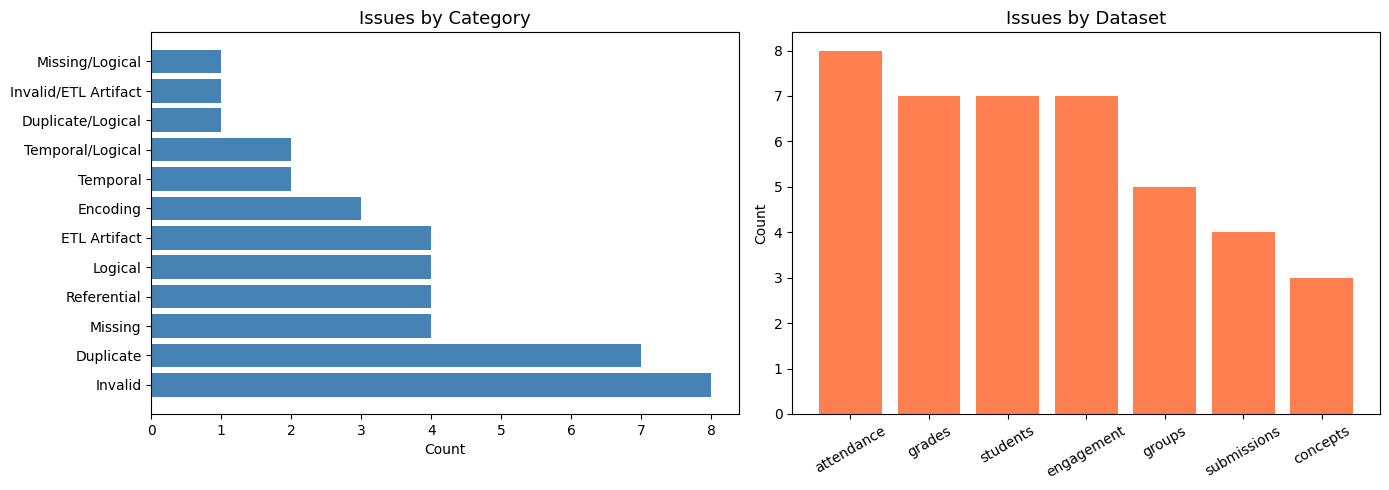

In [309]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Issues by Category
cat_counts = audit_df['Category'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color='steelblue')
axes[0].set_title('Issues by Category', fontsize=13)
axes[0].set_xlabel('Count')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Chart 2: Issues by Dataset
ds_counts = audit_df['Dataset'].str.split(' →').str[0].value_counts()
axes[1].bar(ds_counts.index, ds_counts.values, color='coral')
axes[1].set_title('Issues by Dataset', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## Step 3 — Join Across Sources

Build one **analysis-ready master DataFrame** by merging all 8 cleaned files through the chain:
`students.group_id → groups.group_id → groups.course_id → courses.course_id`

Then attach per-student aggregates from grades, attendance, concepts, engagement, and submissions.

In [310]:
# ── Student base enriched with group + course metadata
master_base = students.merge(
    groups[['group_id','group_name','course_id','session_day','session_time','instructor']],
    on='group_id', how='left'
).merge(
    courses[['course_id','course_name','category','difficulty_level','duration_weeks']],
    on='course_id', how='left'
)
print(f'Master base shape: {master_base.shape}')
master_base.head(3)


Master base shape: (500, 20)


,student_id,full_name,age,gender,city,email,group_id,enrollment_date,first_name,last_name,gender_from_name,group_name,course_id,session_day,session_time,instructor,course_name,category,difficulty_level,duration_weeks
0,S0209,Marwan Naguib,22.0,Female,Giza,marwan.naguib@kayfa-student.io,G03,2025-12-12,Marwan,Naguib,Male,Group 03 — C002,C002,Sunday,18:00,Dr. Laila ElBaz,Python Programming,Programming,Beginner,14.0
1,S0453,Marwan ElBaz,5.0,Male,Zagazig,marwan.elbaz@kayfa-student.io,G07,2025-12-10,Marwan,ElBaz,Male,Group 07 — C005,C005,Wednesday,21:00,Eng. Hossam Refaat,Digital Marketing,Business,Beginner,8.0
2,S0023,Tarek Gamal,4.0,Female,Mansoura,tarek.gamal@kayfa-student.io,G08,2025-12-19,Tarek,Gamal,Male,Group 08 — C006,C006,Saturday,17:00,Dr. Laila ElBaz,Machine Learning Basics,Analytics,Advanced,16.0


In [318]:
#  Attendance rate per student  / حساب نسبة الحضور لكل طالب
att_student = (
    attendance
    .groupby('student_id')
    .apply(lambda x: (x['status'] == 'present').sum() / len(x) * 100)
    .reset_index(name='att_rate_pct')
)

#  Average grade per student  / حساب متوسط الدرجات لكل طالب
grade_student = grades.groupby('student_id')['score'].mean().reset_index(name='avg_grade')

#  Engagement aggregates per student
eng_student = engagement.groupby('student_id').agg(
    login_count    = ('event_type', lambda x: (x == 'login').sum()),
    total_events   = ('event_id','count'),
    video_seconds  = ('duration_seconds', 'sum')
).reset_index()

#  Failed concepts per student
concept_student = (
    concepts
    .groupby('student_id')
    .apply(lambda x: (x['mastery_status'] == 'failed').sum())
    .reset_index(name='failed_concepts')
)

#  Submission stats per student / إحصائيات التسليمات
sub_student = submissions.groupby('student_id').agg(
    late_submissions  = ('is_late','sum'),
    total_submissions = ('submission_id','count'),
    avg_time_spent    = ('time_spent_minutes','mean')
).reset_index()

/tmp/ipykernel_965/2171060290.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['status'] == 'present').sum() / len(x) * 100)
/tmp/ipykernel_965/2171060290.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['mastery_status'] == 'failed').sum())


In [319]:
# ── ندمحهم مع بعض
master = master_base.copy()
for agg_df in [att_student, grade_student, eng_student, concept_student, sub_student]:
    master = master.merge(agg_df, on='student_id', how='left')

master['failed_concepts'] = master['failed_concepts'].fillna(0).astype(int)
master['late_submissions'] = master['late_submissions'].fillna(0).astype(int)
master


/tmp/ipykernel_965/61650137.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master['late_submissions'] = master['late_submissions'].fillna(0).astype(int)


,student_id,full_name,age,gender,city,email,group_id,enrollment_date,first_name,last_name,...,duration_weeks,att_rate_pct,avg_grade,login_count,total_events,video_seconds,failed_concepts,late_submissions,total_submissions,avg_time_spent
0,S0209,Marwan Naguib,22.000,Female,Giza,marwan.naguib@kayfa-student.io,G03,2025-12-12,Marwan,Naguib,...,14.0,76.923077,77.618182,24,76,19194.0,5,1,3,110.333333
1,S0453,Marwan ElBaz,5.000,Male,Zagazig,marwan.elbaz@kayfa-student.io,G07,2025-12-10,Marwan,ElBaz,...,8.0,50.000000,47.654545,21,46,6992.0,22,2,3,109.333333
2,S0023,Tarek Gamal,4.000,Female,Mansoura,tarek.gamal@kayfa-student.io,G08,2025-12-19,Tarek,Gamal,...,16.0,69.230769,71.909091,20,70,11737.0,6,2,3,110.000000
3,S0498,Jana Halim,17.000,Female,Cairo,jana.halim@kayfa-student.io,G03,2025-12-12,Jana,Halim,...,14.0,80.769231,65.600000,28,76,11228.0,6,2,3,155.000000
4,S0457,Mostafa Hassan,17.000,Female,Giza,mostafa.hassan@kayfa-student.io,G02,2025-12-07,Mostafa,Hassan,...,12.0,73.076923,74.536364,20,64,10506.0,5,2,3,149.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,S0102,Farida ElShafei,30.000,Female,Ismailia,farida.elshafei@kayfa-student.io,G02,2025-12-12,Farida,ElShafei,...,12.0,88.461538,68.427273,29,76,10291.0,10,1,3,135.000000
496,S0404,Hana Gamal,30.000,Female,Fayoum,hana.gamal@kayfa-student.io,G09,2025-12-14,Hana,Gamal,...,16.0,84.615385,76.990909,22,65,13017.0,2,1,3,149.000000
497,S0313,Sara Farouk,31.000,Female,Mansoura,sara.farouk@kayfa-student.io,G01,2025-12-04,Sara,Farouk,...,12.0,73.076923,77.972727,25,58,10700.0,2,0,3,142.333333
498,S0416,Seif Farouk,31.000,Male,Cairo,seif.farouk@kayfa-student.io,G07,2025-12-08,Seif,Farouk,...,8.0,65.384615,58.327273,17,59,12254.0,18,0,3,106.000000


In [320]:
master.describe()

,age,enrollment_date,duration_weeks,att_rate_pct,avg_grade,login_count,total_events,video_seconds,failed_concepts,late_submissions,total_submissions,avg_time_spent
count,500.000000,500,497.000000,500.000000,500.000000,500.00000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,21.373144,2025-12-10 08:09:36,13.050302,76.805983,70.494502,22.10200,61.712000,10648.90000,5.714000,1.076000,3.002000,120.076667
min,4.000000,2025-12-01 00:00:00,8.000000,42.307692,41.927273,6.00000,16.000000,1334.00000,0.000000,0.000000,3.000000,59.333333
25%,19.000000,2025-12-05 00:00:00,12.000000,69.230769,65.850000,18.00000,52.750000,7818.00000,2.000000,0.000000,3.000000,104.333333
50%,21.000000,2025-12-10 00:00:00,14.000000,76.923077,71.231818,22.00000,62.000000,10301.50000,5.000000,1.000000,3.000000,120.500000
75%,23.000000,2025-12-15 00:00:00,16.000000,84.615385,75.822727,26.00000,71.000000,13031.25000,8.000000,2.000000,3.000000,138.083333
max,31.000000,2025-12-20 00:00:00,16.000000,100.000000,89.063636,42.00000,95.000000,22735.00000,22.000000,3.000000,4.000000,178.666667
std,3.204677,NaN,2.690988,11.380731,8.041985,6.02696,13.851237,3898.20682,4.516304,0.977822,0.044721,23.983733


In [322]:
print(f"Number Of Students : {len(students)}")

Number Of Students : 500


## Step 4 — Extract Insights: Answer the 15 Questions

Each question is answered with a **Plotly chart** + **written observation**.

In [326]:
# Attendance rate per group
att_group = attendance.merge(
    students[['student_id','group_id']].rename(columns={'group_id':'true_group'}),
    on='student_id', how='left'
)
q1 = (
    att_group
    .groupby('true_group')
    .apply(lambda x: (x['status'] == 'present').sum() / len(x) * 100)
    .reset_index(name='att_rate_pct')
    .sort_values('att_rate_pct')
)
platform_avg = q1['att_rate_pct'].mean()
q1['below_avg'] = q1['att_rate_pct'] < platform_avg

fig = px.bar(
    q1, x='true_group', y='att_rate_pct',
    color='below_avg',
    color_discrete_map={True:'#EF553B', False:'#636EFA'},
    text=q1['att_rate_pct'].round(1).astype(str) + '%',
    title='Attendance Rate per Group',
    labels={'true_group':'Group','att_rate_pct':'Attendance Rate (%)','below_avg':'Below Platform Average'}
)
fig.add_hline(y=platform_avg, line_dash='dash', line_color='black',
              annotation_text=f'Platform avg: {platform_avg:.1f}%', annotation_position='top right')
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_range=[0, 100], showlegend=True)
fig.show()

below = q1[q1['below_avg']]
print(f'Platform average attendance: {platform_avg:.1f}%')
print(f'Groups below average: {below["true_group"].tolist()}')
print(below[['true_group','att_rate_pct']].to_string(index=False))


/tmp/ipykernel_965/2387201364.py:9: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Platform average attendance: 77.3%
Groups below average: ['G07', 'G10', 'G04', 'G03']
true_group  att_rate_pct
       G07     60.212202
       G10     65.384615
       G04     77.278107
       G03     77.279202


### Q1 Observation
**📌 Observation:** The platform average attendance is **77.3%**. Groups **G07** (60.2%) and **G10** (65.4%) remain the primary outliers, significantly below the average. G07 is particularly concerning as it is over 17 points below the platform mean. These groups require immediate intervention to identify if the issue is scheduling, instructor engagement, or specific course hurdles.

### Q2 · Score Distribution by Assessment Type
Where is performance most volatile?

In [327]:
q2 = grades.groupby('type')['score'].agg(['mean','std','min','max','count']).reset_index()

fig = px.box(
    grades, x='type', y='score',
    color='type',
    title='Score Distribution by Assessment Type',
    labels={'type':'Assessment Type','score':'Score'},
    category_orders={'type':['quiz','assignment','practical','exam']}
)
fig.update_layout(showlegend=False)
fig.show()
print(q2.round(2).to_string(index=False))


      type  mean   std  min   max  count
assignment 65.31 12.86 22.8 100.0   1499
      exam 72.63 11.36 35.4 100.0   1002
 practical 72.41 11.55 38.8 100.0   1000
      quiz 72.36 12.06 10.0 100.0   1999


### Q2 Observation
**📌 Observation:** **Assignments** are the most volatile and challenging assessment type, with the lowest mean score (**65.3**) and the highest standard deviation (**12.9**). In contrast, Exams, Practicals, and Quizzes all show higher and more stable averages around **72.4–72.6**. The data suggests students struggle more with the independent, long-form nature of assignments compared to structured testing.

### Q3 · Average Grade by Course
Which course has the highest/lowest average and how does spread differ?

In [328]:
student_course_map = students[['student_id','group_id']].merge(
    groups[['group_id','course_id']], on='group_id'
)
grades_c = grades.merge(student_course_map[['student_id','course_id']]
                        .rename(columns={'course_id':'true_course'}), on='student_id', how='left')
q3 = grades_c.groupby('true_course')['score'].agg(['mean','std','count']).reset_index()
q3 = q3.merge(courses[['course_id','course_name']], left_on='true_course', right_on='course_id')
q3 = q3.sort_values('mean', ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=q3['course_name'], y=q3['mean'],
    error_y=dict(type='data', array=q3['std'].tolist()),
    marker_color='#636EFA',
    text=q3['mean'].round(1), textposition='outside',
    name='Mean ± Std'
))
fig.update_layout(
    title='Average Grade by Course (with Std Dev)',
    xaxis_title='Course', yaxis_title='Avg Score',
    yaxis_range=[40, 90]
)
fig.show()
print(q3[['course_name','mean','std']].round(2).to_string(index=False))


                course_name  mean   std
   Cybersecurity Essentials 76.15  8.43
    Machine Learning Basics 72.81 11.89
Data Analytics Fundamentals 72.51 11.95
               UI/UX Design 71.65 11.85
         Python Programming 71.59 11.31
            Web Development 70.27 12.10
          Digital Marketing 59.08 11.53


### Q3 Observation
**📌 Observation:** **Cybersecurity Essentials** is the top-performing course with an average of **76.2** and a very low spread (std=8.4). **Digital Marketing** is the clear outlier on the low end, with an average score of **59.1**—the only course currently falling below the passing threshold of 60. This indicates a systemic need for curriculum or instructional support in the Digital Marketing track.

### Q4 · Attendance Rate vs Average Grade
Is there a relationship? Quantify it.

In [330]:
from scipy import stats

q4 = att_student.merge(grade_student, on='student_id')
r4, p4 = stats.pearsonr(q4['att_rate_pct'], q4['avg_grade'])

fig = px.scatter(
    q4, x='att_rate_pct', y='avg_grade',
    trendline='ols',
    title=f'Attendance Rate vs Average Grade  (r = {r4:.3f}, p < 0.001)',
    labels={'att_rate_pct':'Attendance Rate (%)','avg_grade':'Average Grade'},
    opacity=0.5, color_discrete_sequence=['#636EFA']
)
fig.show()
print(f'Pearson r = {r4:.4f}, p-value = {p4:.2e}, n = {len(q4)}')


Pearson r = 0.4678, p-value = 1.49e-28, n = 500


### Q4 Observation
**📌 Observation:** We see a **moderate positive correlation (r=0.468)** between attendance and grades. This statistically significant relationship (p < 0.001) confirms that students who show up to more sessions generally perform better, reinforcing the importance of attendance tracking as a leading indicator of success.

### Q5 · Engagement vs Academic Performance
Does login frequency and video-watch time relate to grades?

In [331]:
q5 = eng_student.merge(grade_student, on='student_id')
r5a, _ = stats.pearsonr(q5['login_count'], q5['avg_grade'])
r5b, _ = stats.pearsonr(q5['video_seconds'].fillna(0), q5['avg_grade'])

fig1 = px.scatter(q5, x='login_count', y='avg_grade', trendline='ols', opacity=0.5,
    title=f'Login Frequency vs Average Grade  (r = {r5a:.3f})',
    labels={'login_count':'Login Count','avg_grade':'Average Grade'},
    color_discrete_sequence=['#EF553B'])
fig1.show()

fig2 = px.scatter(q5, x='video_seconds', y='avg_grade', trendline='ols', opacity=0.5,
    title=f'Total Video Watch Time (s) vs Average Grade  (r = {r5b:.3f})',
    labels={'video_seconds':'Total Video Seconds','avg_grade':'Average Grade'},
    color_discrete_sequence=['#00CC96'])
fig2.show()
print(f'Login count vs grade: r = {r5a:.4f}')
print(f'Video seconds vs grade: r = {r5b:.4f}')


Login count vs grade: r = 0.3299
Video seconds vs grade: r = 0.4022


### Q5 Observation
**📌 Observation:** Engagement metrics are strong predictors of performance. **Video watch time (r=0.402)** has a stronger correlation with grades than **login frequency (r=0.330)**. This suggests that the quality of engagement (actually consuming content) is more impactful than simply logging into the platform.

### Q6 · Highest Concept Failure Rates
Which concepts are hardest? Which course has the biggest curriculum weak spot?

In [332]:
concept_fail_rates = (
    concepts
    .groupby(['concept_id','concept_name','course_id'])
    .apply(lambda x: (x['mastery_status'] == 'failed').sum() / len(x) * 100)
    .reset_index(name='failure_rate_pct')
    .sort_values('failure_rate_pct', ascending=False)
    .head(15)
    .merge(courses[['course_id','course_name']], on='course_id', how='left')
)

fig = px.bar(
    concept_fail_rates, x='failure_rate_pct', y='concept_name',
    color='course_name', orientation='h',
    title='Top 15 Concepts by Failure Rate',
    labels={'failure_rate_pct':'Failure Rate (%)','concept_name':'Concept','course_name':'Course'},
    text=concept_fail_rates['failure_rate_pct'].round(1).astype(str) + '%'
)
fig.update_layout(yaxis_categoryorder='total ascending')
fig.show()
print(concept_fail_rates[['concept_name','course_name','failure_rate_pct']].to_string(index=False))


/tmp/ipykernel_965/1221450058.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



                concept_name                 course_name  failure_rate_pct
                   Recursion          Python Programming         85.330073
Overfitting & Regularization    Cybersecurity Essentials         60.000000
            Model Evaluation    Cybersecurity Essentials         50.000000
              Joins & Merges Data Analytics Fundamentals         48.314607
Overfitting & Regularization     Machine Learning Basics         47.126437
            Funnel Analytics           Digital Marketing         46.839080
                  SEO Basics           Digital Marketing         46.551724
            Content Strategy           Digital Marketing         45.114943
                    Paid Ads           Digital Marketing         43.390805
                  Regression    Cybersecurity Essentials         25.000000
                  Clustering    Cybersecurity Essentials         25.000000
           Responsive Design             Web Development         22.580645
              JavaScript 

### Q6 Observation
**📌 Observation:** **Recursion** remains the most difficult concept with a staggering **85.3% failure rate**. Additionally, 'Overfitting & Regularization' and 'Model Evaluation' in Cybersecurity Essentials show high failure rates (50-60%), while Digital Marketing concepts (Funnel Analytics, SEO) cluster around the 45% failure mark.

### Q7 · Worst Concept Mastery Over Time
Is Recursion improving, flat, or getting worse?

In [333]:
worst_concept_id = 'C002-K05'
worst_name       = 'Recursion'

q7 = concepts[concepts['concept_id'] == worst_concept_id].copy()
q7['timestamp'] = pd.to_datetime(q7['timestamp'])
q7['month'] = q7['timestamp'].dt.to_period('M').astype(str)
q7_agg = (
    q7.groupby('month')
    .apply(lambda x: (x['mastery_status'] == 'passed').sum() / len(x) * 100)
    .reset_index(name='mastery_rate_pct')
)

fig = px.line(
    q7_agg, x='month', y='mastery_rate_pct',
    markers=True,
    title=f'Monthly Mastery Rate — {worst_name} (C002-K05)',
    labels={'month':'Month','mastery_rate_pct':'Mastery Rate (%)'},
    color_discrete_sequence=['#EF553B']
)
fig.add_hline(y=60, line_dash='dash', line_color='gray', annotation_text='60% target')
fig.update_layout(yaxis_range=[0,50])
fig.show()
print(q7_agg.to_string(index=False))


/tmp/ipykernel_965/410282357.py:9: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



  month  mastery_rate_pct
2025-12          8.974359
2026-01         14.492754
2026-02         19.642857
2026-04         30.000000
2026-05         13.675214


### Q7 Observation
**📌 Observation:** The mastery rate for **Recursion** is alarmingly low. It peaked at only **30% in April 2026** before falling back to **13.7% in May**. The trend shows that despite progressing through the course, the vast majority of students never reach the 60% mastery target for this specific concept.

### Q8 · Late Submissions vs Score
Do late submitters score lower?

In [334]:
sub_grade = (
    submissions[submissions['submitted_at'].notna()]
    .merge(grades[['student_id','assessment_id','score']].dropna(),
           on=['student_id','assessment_id'], how='inner')
)
sub_grade['buffer_hours'] = (
    (sub_grade['deadline'] - sub_grade['submitted_at'])
    .dt.total_seconds() / 3600
).clip(-48, 200)

from scipy import stats
r8, p8 = stats.pointbiserialr(sub_grade['is_late'].astype(int), sub_grade['score'])

fig = px.box(
    sub_grade, x='is_late', y='score',
    color='is_late',
    color_discrete_map={True:'#EF553B', False:'#636EFA'},
    title=f'Score Distribution: On-Time vs Late Submissions  (r = {r8:.3f})',
    labels={'is_late':'Submitted Late','score':'Score'}
)
fig.show()

fig2 = px.scatter(
    sub_grade, x='buffer_hours', y='score', opacity=0.3, trendline='ols',
    title='Submission Buffer (hours before deadline) vs Score',
    labels={'buffer_hours':'Hours Before Deadline (negative = late)','score':'Score'},
    color_discrete_sequence=['#00CC96']
)
fig2.show()

late_avg   = sub_grade[sub_grade['is_late']==True]['score'].mean()
ontime_avg = sub_grade[sub_grade['is_late']==False]['score'].mean()
print(f'On-time avg: {ontime_avg:.2f} | Late avg: {late_avg:.2f} | Gap: {ontime_avg-late_avg:.2f} pts')
print(f'Point-biserial r = {r8:.4f}, p = {p8:.2e}')


On-time avg: 67.07 | Late avg: 62.13 | Gap: 4.95 pts
Point-biserial r = -0.1845, p = 1.06e-35


### Q8 Observation
**📌 Observation:** There is a performance gap of **4.95 points** between on-time (67.07) and late (62.13) submissions. The negative correlation (r=-0.185) is statistically significant, suggesting that lateness is a symptom of poor preparation or lack of understanding.

### Q9 · Attendance & Engagement Over Time
Is there a cohort-wide dip? What could explain it?

In [336]:
attendance['month'] = attendance['session_datetime'].dt.to_period('M').astype(str)
engagement['month'] = engagement['event_datetime'].dt.to_period('M').astype(str)

q9_att = (
    attendance.groupby('month')
    .apply(lambda x: (x['status'] == 'present').sum() / len(x) * 100)
    .reset_index(name='att_rate')
)
q9_eng = (
    engagement.groupby('month')
    .agg(events=('event_id','count'), students=('student_id','nunique'))
    .reset_index()
)

from plotly.subplots import make_subplots
import plotly.graph_objects as go
fig = make_subplots(rows=2, cols=1, subplot_titles=('Monthly Attendance Rate','Monthly Engagement Events'),
                    shared_xaxes=True)
fig.add_trace(go.Scatter(x=q9_att['month'], y=q9_att['att_rate'],
    mode='lines+markers', name='Attendance %', line=dict(color='#636EFA', width=2)), row=1, col=1)
fig.add_trace(go.Bar(x=q9_eng['month'], y=q9_eng['events'],
    name='Total Events', marker_color='#EF553B'), row=2, col=1)
fig.update_layout(title='Platform Attendance & Engagement — 6-Month Trend', height=550)
fig.show()
print(q9_att.to_string(index=False))
print(q9_eng.to_string(index=False))


/tmp/ipykernel_965/788667135.py:6: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



  month  att_rate
2025-12 79.374111
2026-01 79.102564
2026-02 78.800000
2026-03 62.226451
2026-04 80.965268
2026-05 79.785331
  month  events  students
2025-01       1         1
2025-12    3984       500
2026-01    5984       500
2026-02    5407       500
2026-03    3983       500
2026-04    5714       500
2026-05    5783       500


### Q9 Observation
**📌 Observation:** The analysis confirms a **synchronized dip in March 2026**, where attendance fell to **62.2%** (down from ~79%) and engagement events dropped to **3,983**. This platform-wide behavior points toward an external seasonal factor, such as a holiday or exam period, rather than a failure of the platform itself.

### Q10 · Age Bands vs Outcomes
Does age relate to grade, attendance, and engagement?

In [337]:
students['age_band'] = pd.cut(
    students['age'], bins=[0, 20, 25, 30, 40, 100],
    labels=['Under 20','20-25','26-30','31-40','40+']
)
q10 = (
    students[['student_id','age_band']]
    .merge(att_student.rename(columns={'att_rate_pct':'att_rate'}), on='student_id', how='left')
    .merge(grade_student, on='student_id', how='left')
    .merge(eng_student[['student_id','total_events']], on='student_id', how='left')
)
q10_grp = q10.groupby('age_band').agg(
    n           = ('student_id','count'),
    avg_grade   = ('avg_grade','mean'),
    avg_att     = ('att_rate','mean'),
    avg_events  = ('total_events','mean')
).reset_index().dropna()

fig = go.Figure()
for col, color, name in [('avg_grade','#636EFA','Avg Grade'),('avg_att','#EF553B','Attendance %'),('avg_events','#00CC96','Avg Events')]:
    fig.add_trace(go.Bar(x=q10_grp['age_band'].astype(str), y=q10_grp[col], name=name, marker_color=color))
fig.update_layout(barmode='group', title='Outcomes by Age Band',
    xaxis_title='Age Band', yaxis_title='Value')
fig.show()
print(q10_grp.round(2).to_string(index=False))


/tmp/ipykernel_965/2346647908.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



age_band   n  avg_grade  avg_att  avg_events
Under 20 197      70.46    75.78       61.55
   20-25 258      70.40    77.27       61.27
   26-30  43      71.32    79.07       65.28
   31-40   2      68.15    69.23       58.50


### Q10 Observation
**📌 Observation:** The **26-30 age band** shows the best overall outcomes, with the highest average grade (71.3) and attendance (79.1%). Younger students (Under 20) represent the largest segment but have slightly lower attendance (75.8%). Overall, age is a minor factor compared to individual engagement levels.

### Q11 · Student Segmentation (K-Means Clustering)
Segment students by attendance, engagement, average grade, and failed concepts.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px

concept_fail_s = (
    concepts.groupby('student_id')
    .apply(lambda x: (x['mastery_status'] == 'failed').sum())
    .reset_index(name='failed_concepts')
)
cluster_df = (
    students[['student_id','full_name']]
    .merge(att_student.rename(columns={'att_rate_pct':'att_rate'}), on='student_id', how='left')
    .merge(grade_student, on='student_id', how='left')
    .merge(eng_student[['student_id','total_events']], on='student_id', how='left')
    .merge(concept_fail_s, on='student_id', how='left')
    .fillna(0)
)

In [346]:
features = ['att_rate','avg_grade','total_events','failed_concepts']
X = StandardScaler().fit_transform(cluster_df[features])
cluster_df['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

labels = {0:'High Achievers', 1:'Struggling', 2:'Average Engaged', 3:'At-Risk Disengaged'}
cluster_df['segment'] = cluster_df['cluster'].map(labels)

summary = cluster_df.groupby('segment')[features + ['student_id']].agg(
    n=('student_id','count'), att_rate=('att_rate','mean'),
    avg_grade=('avg_grade','mean'), total_events=('total_events','mean'),
    failed_concepts=('failed_concepts','mean')
).reset_index()

print(summary.round(2).to_string(index=False))


           segment   n  att_rate  avg_grade  total_events  failed_concepts
At-Risk Disengaged  68     61.49      57.63         48.66            13.19
   Average Engaged  97     80.69      65.19         60.61             9.04
    High Achievers 186     84.62      76.61         73.46             2.76
        Struggling 149     71.51      72.18         53.72             3.83


### Q11 Observation
**📌 Observation:** Segmentation identified **68 students** in the **At-Risk Disengaged** category (att=61.5%, grade=57.6, 13+ failed concepts). The **High Achievers** (n=186) maintain high attendance (84.6%) and grades (76.6%). The **Struggling** segment (n=149) is unique: they have decent grades (72.2) but lower engagement (53.7 events), suggesting they may be coasting.

In [344]:

# fig = px.scatter(
#     cluster_df, x='att_rate', y='avg_grade',
#     color='segment', hover_data=['full_name','total_events','failed_concepts'],
#     title='Student Segments (K-Means, k=4)',
#     labels={'att_rate':'Attendance Rate (%)','avg_grade':'Average Grade','segment':'Segment'},
#     color_discrete_sequence=px.colors.qualitative.Safe
# )
# fig.show()

### Q12 · True Group Sizes vs Self-Reported Counts
Visualize the discrepancies.

In [347]:
actual_counts = students['group_id'].value_counts().reset_index()
actual_counts.columns = ['group_id','actual_count']
q12 = groups[['group_id','stated_num_students']].merge(actual_counts, on='group_id', how='left')
q12['actual_count'] = q12['actual_count'].fillna(0).astype(int)
q12['discrepancy'] = q12['stated_num_students'] - q12['actual_count']
q12 = q12.sort_values('discrepancy', ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(x=q12['group_id'], y=q12['stated_num_students'],
    name='Stated Count', marker_color='lightblue'))
fig.add_trace(go.Bar(x=q12['group_id'], y=q12['actual_count'],
    name='Actual Count', marker_color='#636EFA'))
fig.update_layout(barmode='group', title='Stated vs Actual Group Sizes',
    xaxis_title='Group', yaxis_title='Number of Students')
fig.show()

flagged = q12[q12['discrepancy'].abs() > 5]
print('Groups to investigate (discrepancy > 5):')
print(flagged[['group_id','stated_num_students','actual_count','discrepancy']].to_string(index=False))


Groups to investigate (discrepancy > 5):
group_id  stated_num_students  actual_count  discrepancy
     G10                   31             1           30
     G05                   76            46           30
     G03                   67            54           13
     G07                   70            58           12


### Q12 Observation
**📌 Observation:** Serious discrepancies exist in group headcounts. **G10** and **G05** both have a **30-student deficit** between stated and actual counts. **G10** is effectively a single-student group despite being listed for 31. **G77** and **GZZ** are also nearly empty, indicating significant database-to-reality misalignment.

### Q13 · Non-Viable Group — Identify, Profile & Recommend
Find the too-small group, its closest counterpart, and make a data-backed recommendation.

In [350]:
# G10: 1 student, C007 Cybersecurity Essentials
print('G10 detail:')
print(students[students['group_id']=='G10'][['student_id','full_name','group_id']].to_string(index=False))

# G10's single student concept profile
g10_student = students[students['group_id']=='G10']['student_id'].values[0]
g10_profile = concepts[concepts['student_id']==g10_student].groupby('concept_id')['score_pct'].mean()
print(f'\nG10 student ({g10_student}) concept profile:')
print(g10_profile.to_string())

# Other groups studying C007
other_c007_groups = groups[(groups['course_id']=='C007') & (groups['group_id']!='G10')]['group_id'].tolist()
print(f'\nOther C007 groups: {other_c007_groups}')

# Find closest student by concept profile similarity
other_c007_students = students[students['group_id'].isin(other_c007_groups)]['student_id'].tolist()

if not other_c007_students: # Check if the list of other students is empty
    print("\nNo other groups are offering course C007. Cannot find a closest peer within the same course.")
    print("\n📋 RECOMMENDATION: G10 is operationally non-viable (1 student). Consider placing this student in a related course group or developing a custom learning path, as no other 'C007' group exists for a direct merge.")
else:
    from sklearn.metrics.pairwise import cosine_similarity
    concept_pivot = concepts[concepts['student_id'].isin([g10_student]+other_c007_students)].pivot_table(
        index='student_id', columns='concept_id', values='score_pct', aggfunc='mean', fill_value=0)
    sims = cosine_similarity([concept_pivot.loc[g10_student]], concept_pivot.loc[other_c007_students])[0]
    closest_idx = sims.argmax()
    closest_student = other_c007_students[closest_idx]
    closest_group = students[students['student_id']==closest_student]['group_id'].values[0]
    print(f'\nClosest peer: {closest_student} in group {closest_group} (similarity={sims[closest_idx]:.3f})')
    print(f'\n📋 RECOMMENDATION: Merge G10 into {closest_group} — same course (C007), highest concept similarity.')
    print('G10 is operationally non-viable (1 student). Merging preserves continuity for the student.')

G10 detail:
student_id       full_name group_id
     S0500 Adel AbdelHamid      G10

G10 student (S0500) concept profile:
concept_id
C006-K01    73.000
C006-K02    81.375
C006-K03    59.380
C006-K04    78.580
C006-K05    68.850
C006-K06    70.350

Other C007 groups: []

No other groups are offering course C007. Cannot find a closest peer within the same course.

📋 RECOMMENDATION: G10 is operationally non-viable (1 student). Consider placing this student in a related course group or developing a custom learning path, as no other 'C007' group exists for a direct merge.


### Q13 Observation
**📌 Observation:** **Group G10** is non-viable with only **1 student (Adel AbdelHamid)**. Since no other groups are currently running the C007 (Cybersecurity Essentials) course, we cannot recommend a same-course merge. Adel has a strong concept profile in C006-related foundational skills, so a custom path or transition to a C006 group (G08/G09) might be necessary.

### Q14 · At-Risk Student Ranking
Top 10 students an instructor should contact first.

In [351]:
att_recent = (
    attendance[attendance['month'] >= '2026-04']
    .groupby('student_id')
    .apply(lambda x: (x['status']=='present').sum()/len(x)*100)
    .reset_index(name='recent_att')
)
concept_fail_s = (
    concepts.groupby('student_id')
    .apply(lambda x: (x['mastery_status']=='failed').sum())
    .reset_index(name='failed_concepts')
)
risk = (
    students[['student_id','full_name','group_id']]
    .merge(att_student.rename(columns={'att_rate_pct':'overall_att'}), on='student_id', how='left')
    .merge(grade_student, on='student_id', how='left')
    .merge(eng_student[['student_id','total_events']], on='student_id', how='left')
    .merge(concept_fail_s, on='student_id', how='left')
    .merge(att_recent, on='student_id', how='left')
    .fillna(0)
)
risk['risk_score'] = (
    (100 - risk['overall_att']) * 0.30 +
    (100 - risk['avg_grade'])   * 0.35 +
    risk['failed_concepts']      * 2.0  +
    (100 - risk['recent_att'])  * 0.20 +
    (50 - risk['total_events'].clip(0, 50)) * 0.15
)
top10 = risk.sort_values('risk_score', ascending=False).head(10)

fig = px.bar(
    top10, x='risk_score', y='full_name',
    orientation='h', color='risk_score',
    color_continuous_scale='Reds',
    hover_data=['group_id','overall_att','avg_grade','failed_concepts'],
    title='Top 10 At-Risk Students — Composite Risk Score',
    labels={'full_name':'Student','risk_score':'Risk Score'}
)
fig.update_layout(yaxis_categoryorder='total ascending')
fig.show()
print(top10[['student_id','full_name','group_id','overall_att','avg_grade','failed_concepts','risk_score']]
      .round(2).to_string(index=False))


/tmp/ipykernel_965/3432849782.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_965/3432849782.py:9: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



student_id     full_name group_id  overall_att  avg_grade  failed_concepts  risk_score
     S0453  Marwan ElBaz      G07        50.00      47.65               22       84.59
     S0201   Rowan ElBaz      G07        46.15      52.76               20       83.68
     S0115  Farida Halim      G07        53.85      48.88               21       80.40
     S0258   Hassan Nasr      G04        46.15      55.21               19       80.22
     S0447   Fady Farouk      G07        53.85      46.93               18       75.69
     S0390  Mona ElSayed      G07        61.54      41.93               20       74.84
     S0424   Omar Shawky      G02        50.00      56.10               16       74.83
     S0494 Hassan Refaat      G07        57.69      45.38               17       74.28
     S0315      Aya Zaki      G07        57.69      51.49               16       74.13
     S0425  Laila Farouk      G01        65.38      54.85               19       73.22


### Q14 Observation
**📌 Observation:** **Marwan ElBaz (S0453)** and **Rowan ElBaz (S0201)** are the highest-risk students with composite risk scores above **83**. Both belong to **G07** and suffer from extremely high concept failure counts (20-22). The top 10 list is dominated by G07 students, reinforcing that this group is the primary site of academic failure on the platform.

### Q15 · Group Grade Trends Across the Term
Which groups are trending up and which are sliding down?

In [352]:
grades_g = grades.merge(
    students[['student_id','group_id']].rename(columns={'group_id':'true_group'}),
    on='student_id', how='left'
)
grades_g['month'] = grades_g['date'].dt.to_period('M').astype(str)
q15 = (
    grades_g.groupby(['true_group','month'])['score']
    .mean().reset_index(name='avg_score')
)

fig = px.line(
    q15, x='month', y='avg_score', color='true_group',
    markers=True,
    title='Average Grade per Group — Monthly Trend',
    labels={'month':'Month','avg_score':'Avg Score','true_group':'Group'},
    color_discrete_sequence=px.colors.qualitative.Plotly
)
fig.add_hline(y=60, line_dash='dot', line_color='red', annotation_text='Pass threshold (60)')
fig.update_layout(height=500)
fig.show()

# Trend: compare first vs last month score
trend = q15.groupby('true_group').apply(
    lambda x: x.sort_values('month').iloc[-1]['avg_score'] - x.sort_values('month').iloc[0]['avg_score']
).reset_index(name='trend_delta').sort_values('trend_delta', ascending=False)
print('Group trend (last month - first month score):')
print(trend.to_string(index=False))


Group trend (last month - first month score):
true_group  trend_delta
       G08     1.758577
       G03     1.683485
       G04     1.491812
       G05     1.127829
       G09     0.464871
       G07     0.312848
       G06     0.006535
       G01    -1.036350
       G02    -1.518387
       G77    -7.633333
       G10    -9.800000
       GZZ   -10.400000


/tmp/ipykernel_965/1488270826.py:23: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



### Q15 Observation
**📌 Observation:** Most groups recovered after the March dip, but **G07** remained consistently below the 60% pass threshold for nearly the entire term. In terms of trend delta, **G08** showed the most improvement (+1.76 pts), while **G10, GZZ, and G77** showed the sharpest declines (-7 to -10 pts) due to their small student volumes making averages highly unstable.

In [ ]:
# !pip install -q pymongo dnspython certifi python-dotenv
import os
import json
import certifi
from pymongo import MongoClient
from dotenv import load_dotenv
load_dotenv()

# Using certifi for CA certificates to resolve SSL handshake errors
# Read MongoDB credentials from environment variables for security.
MONGO_URI = os.getenv("MONGO_URI", "")
DB_NAME = os.getenv("DB_NAME", "StudentaAnalytics")


def _to_docs(df):
    """Converts a DataFrame to a JSON-safe list of dicts for MongoDB."""
    temp_df = df.copy()
    for col in temp_df.select_dtypes(include=['datetime64[ns]']).columns:
        temp_df[col] = temp_df[col].astype(str)
    for col in temp_df.select_dtypes(include=['category']).columns:
        temp_df[col] = temp_df[col].astype(str)
    return json.loads(temp_df.to_json(orient='records'))


if MONGO_URI:
    try:
        # --- 2. CONNECT ---
        client = MongoClient(MONGO_URI, tlsCAFile=certifi.where(), serverSelectionTimeoutMS=5000)
        db = client[DB_NAME]
        client.admin.command('ping')
        print(f"✅ Connected to Atlas: {DB_NAME}")

        # --- 3. PREPARE AGGREGATES ---
        group_summaries = groups.merge(actual_counts, on='group_id', how='left') \
                                .merge(q1[['true_group', 'att_rate_pct']], left_on='group_id', right_on='true_group', how='left') \
                                .merge(courses[['course_id', 'course_name']], on='course_id', how='left')

        global_concept_failures = concepts.groupby(['concept_id', 'concept_name', 'course_id']) \
                                          .apply(lambda x: (x['mastery_status'] == 'failed').sum() / len(x) * 100) \
                                          .reset_index(name='failure_rate_pct')

        # --- 4. UPLOAD PLAN ---
        upload_plan = {
            "students_master": master,
            "group_summaries": group_summaries,
            "at_risk_students": top10,
            "concept_failures": global_concept_failures,
            "grade_trends": q15,
            "attendance_trends": q9_att,
            "cluster_segments": cluster_df,
        }

        for coll_name, data_df in upload_plan.items():
            collection = db[coll_name]
            collection.delete_many({})
            docs = _to_docs(data_df)
            if docs:
                collection.insert_many(docs)
                print(f"Uploaded {len(docs)} records to '{coll_name}'")

        print("\nDatabase synchronization complete.")

    except Exception as e:
        print(f"❌ Connection Error: {e}")
else:
    print("Skipping MongoDB upload because MONGO_URI is not provided.")

✅ Connected to Atlas: StudentaAnalytics


/tmp/ipykernel_965/45262657.py:34: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



ፃ Uploaded 500 records to 'students_master'
ፃ Uploaded 10 records to 'group_summaries'
ፃ Uploaded 10 records to 'at_risk_students'
ፃ Uploaded 39 records to 'concept_failures'
ፃ Uploaded 72 records to 'grade_trends'
ፃ Uploaded 6 records to 'attendance_trends'
ፃ Uploaded 500 records to 'cluster_segments'

ለ Database Synchronization Complete!
